# Detección de Tipos de Spoiler en Clickbait (SemEval 2023 - Task 5 - Subtask 1)

**Autor:** Nicolás Vives

**Descripción:** Este cuaderno aborda la subtarea 1 del benchmark "Webis Clickbait Spoiling Corpus 2022" (SemEval 2023). El objetivo es clasificar qué tipo de spoiler (respuesta) requiere un titular "clickbait": una frase corta (`phrase`), un pasaje o párrafo (`passage`), o múltiples fragmentos (`multi`).

Se parte de una arquitectura base de clasificación de textos con Transformers (DistilBERT) proporcionada en los materiales de la asignatura. El flujo de trabajo es el siguiente:

* **Fase 1: Preparación y EDA**
  El flujo comienza con la carga y el preprocesamiento del texto. A continuación, se realiza un Análisis Exploratorio de Datos (EDA) para observar la distribución de las categorías de *clickbait* y detectar posibles sesgos. Se carga el conjunto de datos estructurando el texto en diferentes formatos para comprobar de que manera se beneficiarán más los diferentes modelos. Ante la presencia del desequilibrio en las clases observado en el EDA, se plantea un experimento específico para contrastar la asignación de pesos (*Class Weights*) frente al *oversampling*.

* **Fase 2: Exploración y selección de arquitecturas**
  Una vez preparados los datos, se inicia una fase de experimentación. Partiendo de un modelo base ligero (DistilBERT), se evalúa el impacto de distintas técnicas de preprocesamiento de texto y variaciones de la arquitectura, como la concatenación de matrices TF-IDF. Posteriormente, el alcance se amplía para evaluar y comparar el rendimiento de diferentes familias de Transformers (RoBERTa, DeBERTa-v3 y Longformer), identificando a los candidatos con mayor potencial.

* **Fase 3: Entrenamiento profundo**
  Las configuraciones más prometedoras de la fase anterior avanzan a un ciclo de entrenamiento completo. En esta etapa se introducen las arquitecturas mixtas. Se inyectan características manuales (metadatos del titular) directamente en la red neuronal de los modelos finalistas. El modelo que demuestra mayor rendimiento general es seleccionado y sometido a técnicas de *fine-Tuning* avanzado para tratar de exprimir todavía más algo de rendimiento.

* **Fase 4: Explicabilidad despliegue**
  Para dotar de transparencia al modelo final, se integra un modelo de lenguaje generativo encargado de justificar, en lenguaje natural, el razonamiento detrás de cada predicción. Se termina con la implementación de una interfaz visual interactiva que permite introducir noticias reales y probar el sistema predictivo y explicativo.

### **IMPORTANTE**:
No ejecutar nada. Al final del notebook hay una celda (justo antes de la sección 4) que contiene lo necesario (incluidas todas las librerías) para poder ejecutar la última sección correspondiente a la interfaz. Se recomienda ejecutarla (menos de 3 min aprox.) y ejecutar la sección 4 completa para ver el funcionamiento del modelo. De cualquier modo, al final del cuaderno se incorpora una captura de la interfaz.

Comenzamos con la instalación e importación de librerías, esta primera celda es heredada del notebook de materiales de la asignatura.

In [ ]:
# instalar librerías. Esta casilla es últil por ejemplo si se ejecuta el cuaderno en Google Colab
# Note que existen otras dependencias como tensorflow, etc. que en este caso se encontrarían ya instaladas
%%capture
%pip uninstall -y tensorflow keras tf-keras transformers ml-dtypes
%pip install -q --no-cache-dir \
  "tensorflow==2.19.0" \
  "tf-keras==2.19.0" \
  "ml-dtypes>=0.5.1,<1.0.0" \
  "transformers==4.38.2" \
  pandas plotly scikit-learn

print('Done!')

In [ ]:
#### Código Nicolás Vives ####

# instalacion de dependencias
!pip install sentencepiece
!pip install gradio -q

%reset -f

# librerías estándar y sistema
import os
import gc
import json
import random
import re
import ast
from collections import Counter

# configuración de Keras
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# entorno (Google Colab)
from google.colab import drive

# manipulación de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

# NLP
import nltk
from nltk.corpus import stopwords

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.multiclass import unique_labels

# TensorFlow / HuggingFace
import tensorflow as tf
import tf_keras as keras
from transformers import (
    DistilBertTokenizer,
    TFDistilBertModel,
    RobertaTokenizer,
    TFRobertaModel,
    AutoTokenizer,
    TFAutoModel,
    pipeline,
    set_seed
)

# interfaz de usuario y despliegue web
import gradio as gr

Ajustes iniciales: semilla, directorio de drive y tamaño de figuras.

In [ ]:
# semillas para reproducibilidad
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

# drive
drive.mount('/content/drive')

# configuraciones visuales para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# verificación de la carpeta de datos
DATA_DIR = '/content/drive/Othercomputers/Mi portátil/UA/Ciencia de Datos/Minería de Textos/Bloque 3. Aplicaciones/Prácticas/Práctica 2/dataset_clickbait'
if not os.path.exists(DATA_DIR):
    print(f"ADVERTENCIA: No se encuentra el directorio {DATA_DIR}.")

Mounted at /content/drive


La celda siguiente contiene las funciones auxiliares necesarias a lo largo del cuaderno.

In [ ]:
#### CÓDIGO NICOLÁS VIVES ####

def predict_model(model, cfg, dataframe, pref='m'):
    """
    model: modelo compilado de TensorFlow/Keras
    cfg: diccionario de configuración (debe contener 'num_labels' y 'mapeo_etiquetas')
    dataframe: DataFrame que contiene el texto a predecir
    pref: identificador para las columnas (labels_[pref], scores_[pref]_[class 1], etc.)
    """
    res = {}

    # Convertir texto crudo a entradas del modelo usando la función configurada
    inputs = cfg['get_inputs_fn'](cfg, cfg['columna_texto'], dataframe)

    # Obtener las probabilidades del modelo
    scores = model.predict(inputs)

    mapeo = cfg['mapeo_etiquetas']
    # Ordenar las clases de texto según su valor numérico (0, 1, 2...)
    # para asignarlas correctamente a cada columna de score
    classes = sorted(mapeo, key=mapeo.get)

    if cfg['num_labels'] == 1:
        res = {f'scores_{pref}': scores[:, 0]}
        # Para clasificación binaria con salida única (sigmoid)
        predicted_indices = (scores[:, 0] > 0.5).astype(int)
    else:
        # Para multiclase, asignamos la probabilidad correspondiente a cada clase
        res = {f'scores_{pref}_{cls.lower()}': score for cls, score in zip(classes, [col for col in scores.T])}
        # Conseguimos el índice con la probabilidad más alta
        predicted_indices = np.argmax(scores, axis=1)

    # Creamos el mapeo inverso {0: 'phrase', 1: 'passage', 2: 'multi'} para volver a texto
    inv_mapeo = {v: k for k, v in mapeo.items()}
    labels = [inv_mapeo[idx] for idx in predicted_indices]
    res[f'labels_{pref}'] = labels

    res = pd.DataFrame(res, columns=sorted(list(res.keys())))
    return res

def evaluate_model_multiclass(y_true, y_pred, y_score=None, pos_label='positive', mapeo_etiquetas=None):
    """
    Evaluación válida para binario y multiclase utilizando mapeo manual.
    """
    print('==== Sumario de la clasificación ==== ')
    print(classification_report(y_true, y_pred))

    print('Accuracy -> {:.2%}\n'.format(accuracy_score(y_true, y_pred)))

    # 1. Graficar matriz de confusión garantizando el orden 0, 1, 2
    if mapeo_etiquetas is not None:
        # Esto asegura el orden estricto: ['phrase', 'passage', 'multi']
        labels_text = sorted(mapeo_etiquetas, key=mapeo_etiquetas.get)
        # Sus valores numéricos: [0, 1, 2]
        labels_num = [mapeo_etiquetas[l] for l in labels_text]
    else:
        labels_num = sorted(unique_labels(y_true, y_pred))
        labels_text = [str(l) for l in labels_num]

    # Calcular la matriz en orden natural [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels_num)

    # Pasamos los datos
    z = cm
    x = labels_text
    y = labels_text
    z_text = [[str(val) for val in row] for row in z]

    fig_cm = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='Viridis')

    fig_cm.update_layout(
        height=400, width=400,
        showlegend=True,
        margin={'t':150, 'l':0},
        title={'text' : 'Matriz de Confusión', 'x':0.5, 'y':0.95, 'xanchor': 'center'},
        xaxis = {'title_text':'Valor Predicho', 'tickangle':45, 'side':'top'},
        yaxis = {'title_text':'Valor Real', 'tickmode':'linear', 'autorange':'reversed'},
    )
    fig_cm.show()

    # 2. Curva ROC (Intacta, Adaptada para Binario y Multiclase)
    if y_score is not None:
        if mapeo_etiquetas is not None:
            classes = sorted(mapeo_etiquetas, key=mapeo_etiquetas.get)
            classes_bin = [mapeo_etiquetas[c] for c in classes]
        else:
            classes = sorted(unique_labels(y_true))
            classes_bin = classes

        if len(classes) == 2:
            if mapeo_etiquetas is not None and isinstance(pos_label, str) and pos_label in mapeo_etiquetas:
                pos_label_num = mapeo_etiquetas[pos_label]
            else:
                pos_label_num = pos_label

            fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=pos_label_num)
            fig_roc = px.area(
                x=fpr, y=tpr,
                title = f'Curva ROC (AUC={auc(fpr, tpr):.4f})',
                labels=dict(x='Ratio Falsos Positivos', y='Ratio Verdaderos Positivos'),
                width=400, height=400
            )
            fig_roc.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)
            fig_roc.update_yaxes(scaleanchor="x", scaleratio=1)
            fig_roc.update_xaxes(constrain='domain')
            fig_roc.show()

        elif len(classes) > 2:
            y_true_bin = label_binarize(y_true, classes=classes_bin)

            fig_roc = go.Figure()
            fig_roc.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)

            for i, cls in enumerate(classes):
                if y_score.ndim == 2:
                    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                    auc_score = auc(fpr, tpr)
                    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{cls} (AUC={auc_score:.4f})', mode='lines'))
                else:
                    print("Advertencia: Para ROC multiclase, y_score debe contener las probabilidades de todas las clases.")
                    break

            fig_roc.update_layout(
                title='Curva ROC Multiclase (OvR)',
                xaxis_title='Ratio Falsos Positivos',
                yaxis_title='Ratio Verdaderos Positivos',
                width=500, height=500,
                yaxis=dict(scaleanchor="x", scaleratio=1),
                xaxis=dict(constrain='domain')
            )
            fig_roc.show()

    print('Done!')

#### FIN CÓDIGO NICOLÁS VIVES ####

## 1. Carga de datos y preprocesamiento inicial

Comenzamos cargando el conjunto de datos para darle un vistazo y observar que formato tiene:

In [ ]:
df = pd.read_json(f'{DATA_DIR}/train.jsonl', lines=True)

df['spoilerType'] = df['tags'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

display(df.head())

df.info()

,uuid,postId,postText,postPlatform,targetParagraphs,targetTitle,targetDescription,targetKeywords,targetMedia,targetUrl,provenance,spoiler,spoilerPositions,tags,spoilerType
0,0af11f6b-c889-4520-9372-66ba25cb7657,532quh,"[Wes Welker Wanted Dinner With Tom Brady, But ...",reddit,[It’ll be just like old times this weekend for...,"Wes Welker Wanted Dinner With Tom Brady, But P...",It'll be just like old times this weekend for ...,"new england patriots, ricky doyle, top stories,","[http://pixel.wp.com/b.gif?v=noscript, http://...",http://nesn.com/2016/09/wes-welker-wanted-dinn...,"{'source': 'anonymized', 'humanSpoiler': 'They...",[how about that morning we go throw?],"[[[3, 151], [3, 186]]]",[passage],passage
1,b1a1f63d-8853-4a11-89e8-6b2952a393ec,411701128456593408,[NASA sets date for full recovery of ozone hole],Twitter,[2070 is shaping up to be a great year for Mot...,Hole In Ozone Layer Expected To Make Full Reco...,2070 is shaping up to be a great year for Moth...,"ozone layer,ozone hole determined by weather,M...",[http://s.m.huffpost.com/assets/Logo_Huffingto...,http://huff.to/1cH672Z,"{'source': 'anonymized', 'humanSpoiler': '2070...",[2070],"[[[0, 0], [0, 4]]]",[phrase],phrase
2,008b7b19-0445-4e16-8f9e-075b73f80ca4,380537005123190784,[This is what makes employees happy -- and it'...,Twitter,"[Despite common belief, money isn't the key to...",Intellectual Stimulation Trumps Money For Empl...,By: Chad Brooks \r\nPublished: 09/18/2013 06:4...,"employee happiness money,employee happiness in...",[http://i.huffpost.com/gen/1359674/images/o-HA...,http://huff.to/1epfeaw,"{'source': 'anonymized', 'humanSpoiler': 'Inte...",[intellectual stimulation],"[[[1, 186], [1, 210]]]",[phrase],phrase
3,31ecf93c-3e21-4c80-949b-aa549a046b93,844567852531286016,[Passion is overrated — 7 work habits you need...,Twitter,"[It’s common wisdom. Near gospel really, and n...","‘Follow your passion’ is wrong, here are 7 hab...",There's a lot more to work that loving your job,"business, work-life, careers",None,None,"{'source': 'anonymized', 'humanSpoiler': None,...",[Purpose connects us to something bigger and i...,"[[[11, 25], [11, 101]], [[17, 56], [17, 85]], ...",[multi],multi
4,31b108a3-c828-421a-a4b9-cf651e9ac859,814186311573766144,[The perfect way to cook rice so that it's per...,Twitter,"[Boiling rice may seem simple, but there is a ...",Revealed: The perfect way to cook rice so that...,The question 'How does one cook rice properly?...,"Quora,users,share,perfect,way,cook,rice",None,None,"{'source': 'anonymized', 'humanSpoiler': None,...",[in a rice cooker],"[[[5, 60], [5, 76]]]",[phrase],phrase


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   uuid               3200 non-null   object
 1   postId             3200 non-null   object
 2   postText           3200 non-null   object
 3   postPlatform       3200 non-null   object
 4   targetParagraphs   3200 non-null   object
 5   targetTitle        3200 non-null   object
 6   targetDescription  2933 non-null   object
 7   targetKeywords     2116 non-null   object
 8   targetMedia        2685 non-null   object
 9   targetUrl          2717 non-null   object
 10  provenance         3200 non-null   object
 11  spoiler            3200 non-null   object
 12  spoilerPositions   3200 non-null   object
 13  tags               3200 non-null   object
 14  spoilerType        3200 non-null   object
dtypes: object(15)
memory usage: 375.1+ KB


Como vemos, el conjunto de datos viene en formato `.jsonl` y contiene metadatos (IDs, imágenes de los tweets, etc.) que no son necesarios para nuestro modelo de lenguaje. Se ha diseñado una función específica para extraer únicamente el texto del titular (*clickbait*) y el texto del artículo (*targetParagraphs*).

Esta función dispone inicialmente de 4 opciones de estructuración de la información (veremos más adelante que se han añadido 2 opciones extra) con el objetivo de estudiar cuál es la información relevante y la que más ayuda a distilbert a clasificar las noticias correctamente. Podríamos pensar que mayor cantidad de texto implica más precisión, pero esto no tiene por qué ser así ya que demasiada información podría confundir al modelo.

 Las opciones iniciales son las siguientes:

- Opción A: pasar solo el titular del clickbait

- Opción B: pasar el titular + primer párrafo del artículo

- Opción C: pasar el titular + todo el artículo

- Opción D: pasar el titular + todo el artículo sin stopwords

Dado que el modelo (DistilBERT) necesita contexto para decidir el tipo de respuesta, concatenamos el la información correspondiente a cada una de las opciones utilizando el token especial `[SEP]` (Separador), que es el estándar en modelos basados en BERT para indicar el fin de una secuencia y el inicio de otra.

###  Extensión del experimento 1

Tras realizar el experimento 1 se contemplan dos opciones extra con el fin de intentar mejorar los resultados del mismo. Estas opciones requieren de una función que se definde a continuación llamada `extraer_parrafos_clave`, la cual extrae el primer párrafo y hasta 2 párrafos extra que contengan palabras clave del clickbait. Las dos opciones añadidas son:

- Opción E: pasar el titular + primer y último párrafo

- Opción F: pasar el titular + primer párrafo + máximo 2 párrafos con palabras clave.

In [ ]:
#### Código Nicolás Vives ####

# descargamos la lista de palabras vacías (stopwords) en inglés
nltk.download('stopwords')
stop_words_english = set(stopwords.words('english'))

def eliminar_stopwords(texto):
    """Función auxiliar para eliminar stopwords de un texto"""
    if not isinstance(texto, str):
        return ""
    palabras = texto.split()
    palabras_limpias = [p for p in palabras if p.lower() not in stop_words_english]
    return " ".join(palabras_limpias)

# EXTENSIÓN POSTERIOR
# función auxiliar para estructurar datos de diferentes formas
def extraer_parrafos_clave(row):
    """
    Extrae el primer párrafo y hasta 2 párrafos extra que contengan
    palabras clave del clickbait.
    """
    clickbait = str(row['clickbait'])
    parrafos = row['targetParagraphs']

    if isinstance(parrafos, str):
        try:
            parrafos = ast.literal_eval(parrafos)
        except:
            parrafos = [parrafos]

    if not parrafos or not isinstance(parrafos, list):
        return ""

    primer_parrafo = str(parrafos[0])

    # extraer palabras clave del clickbait (más de 3 letras)
    clickbait_limpio = re.sub(r'[^\w\s]', '', clickbait.lower())
    palabras_clave = [word for word in clickbait_limpio.split() if len(word) > 3]

    parrafos_relevantes = []
    # buscamos en el resto de párrafos
    for p in parrafos[1:]:
        p_lower = str(p).lower()
        if any(kw in p_lower for kw in palabras_clave):
            parrafos_relevantes.append(str(p))
            if len(parrafos_relevantes) >= 2: # Máximo 2 párrafos extra
                break

    texto_final = primer_parrafo
    if parrafos_relevantes:
        texto_final += " " + " ".join(parrafos_relevantes)

    return texto_final

def cargar_y_preprocesar_clickbait(ruta_archivo):
    """
    Carga un archivo JSONL y extrae los campos relevantes.
    Genera múltiples versiones del texto de entrada para comparar estrategias de contexto.
    """
    datos = []
    with open(ruta_archivo, 'r', encoding='utf-8') as f:
        for linea in f:
            datos.append(json.loads(linea))

    df = pd.DataFrame(datos)

    # etiquetas (0: phrase, 1: passage, 2: multi)
    df['label_text'] = df['tags'].apply(lambda x: x[0] if isinstance(x, list) else x)
    mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
    df['label'] = df['label_text'].map(mapeo_etiquetas)

    # extracción de textos base
    df['clickbait'] = df['postText'].apply(lambda x: x[0] if isinstance(x, list) else x)
    df['primer_parrafo'] = df['targetParagraphs'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
    df['articulo_completo'] = df['targetParagraphs'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
    df['ultimo_parrafo'] = df['targetParagraphs'].apply(lambda x: x[-1] if isinstance(x, list) and len(x) > 0 else "")

    # extracción del Contexto inteligente
    df['contexto_inteligente'] = df.apply(extraer_parrafos_clave, axis=1)

    # OPCIONES DE TEXTO
    # Opción A: pasar solo el titular del clickbait
    df['texto_A'] = df['clickbait']

    # Opción B: pasar el titular + primer párrafo del artículo
    df['texto_B'] = df['clickbait'] + " [SEP] " + df['primer_parrafo']

    # Opción C: pasar el titular + todo el artículo (se truncará en la tokenización)
    df['texto_C'] = df['clickbait'] + " [SEP] " + df['articulo_completo']

    # Opción D: pasar el titular + todo el artículo sin stopwords
    df['articulo_sin_stopwords'] = df['articulo_completo'].apply(eliminar_stopwords)
    df['texto_D'] = df['clickbait'] + " [SEP] " + df['articulo_sin_stopwords']

    # EXTENSIÓN POSTERIOR
    # Opción E: pasar el titular + primer párrafo + último párrafo (Head + Tail)
    df['texto_E'] = df['clickbait'] + " [SEP] " + df['primer_parrafo'] + " [SEP] " + df['ultimo_parrafo']

    # EXTENSIÓN POSTERIOR
    # Opción F: Titular + Primer párrafo + Párrafos con Palabras Clave
    df['texto_F'] = df['clickbait'] + " [SEP] " + df['contexto_inteligente']

    # devolvemos las columnas
    return df[['texto_A', 'texto_B', 'texto_C', 'texto_D', 'texto_E', 'texto_F', 'label_text', 'label']]

# carga de los conjuntos de datos
try:
    df_train = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/train.jsonl')
    df_val = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/validation.jsonl')
    print(f"Datos cargados: {len(df_train)} de entrenamiento y {len(df_val)} de validación.")
except FileNotFoundError as e:
    print(f"Error al cargar los datos: {e}. Revisa la ruta de tus archivos JSONL.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Datos cargados: 3200 de entrenamiento y 800 de validación.


## 2. Análisis Exploratorio de Datos (EDA) y detección de desbalanceo

Antes de entrenar cualquier modelo, exploramos la distribución de las clases. En problemas del mundo real como este es común encontrar clases desbalanceadas lo que puede provocar que el modelo se vuelva vago y prediga siempre la clase mayoritaria.

El siguiente análisis comprobará si existe este problema para, posteriormente, aplicar estrategias de balanceo como penalizaciones en la función de coste (Class Weights) durante el entrenamiento o un oversampling al conjunto.

--- ANÁLISIS DEL CONJUNTO ENTRENAMIENTO ---

Distribución de las clases a predecir:


,Cantidad,Porcentaje (%)
label_text,,
phrase,1367,42.71875
passage,1274,39.81250
multi,559,17.46875


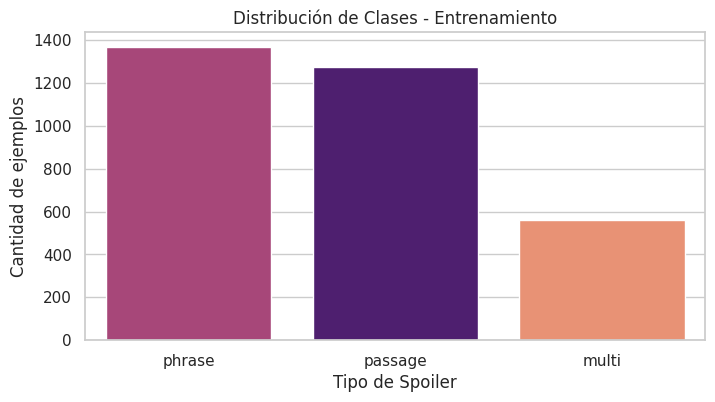


Estadísticas de longitud de los textos concatenados (en palabras):
count     3200.000000
mean       526.553750
std        583.244059
min         13.000000
25%        234.750000
50%        363.000000
75%        654.000000
max      14068.000000
Name: longitud_palabras, dtype: float64


In [ ]:
#### Código Nicolás Vives ####

# función para visualizar la distribución de los datos y su longitud
def analisis_exploratorio(df, nombre_dataset="Entrenamiento"):
    print(f"--- ANÁLISIS DEL CONJUNTO {nombre_dataset.upper()} ---")

    # distribución de clases
    conteo = df['label_text'].value_counts()
    proporcion = df['label_text'].value_counts(normalize=True) * 100

    resumen_clases = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': proporcion})
    print("\nDistribución de las clases a predecir:")
    display(resumen_clases)

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='label_text', order=['phrase', 'passage', 'multi'], hue='label_text', palette='magma', legend=False)
    plt.title(f'Distribución de Clases - {nombre_dataset}')
    plt.xlabel('Tipo de Spoiler')
    plt.ylabel('Cantidad de ejemplos')
    plt.show()

    # análisis de longitud del texto
    # los transformers tienen un límite de tokens (ej. 512 en DistilBERT)
    # veamos cuántas palabras tenemos
    df['longitud_palabras'] = df['texto_C'].apply(lambda x: len(str(x).split()))

    print("\nEstadísticas de longitud de los textos concatenados (en palabras):")
    print(df['longitud_palabras'].describe())

# ejecutamos el análisis sobre el conjunto de entrenamiento
if 'df_train' in locals():
    analisis_exploratorio(df_train, "Entrenamiento")

A partir de los resultados obtenidos en la celda anterior, podemos extraer dos conclusiones antes de continuar con el diseño del modelo:

- Desbalanceo de clases:
  * Las clases `phrase` (42.7%) y `passage` (39.8%) están relativamente equilibradas y dominan el conjunto de datos.
  * Sin embargo, la clase `multi` (17.5%) es una clase minoritaria.
  * Para evitar que el modelo ignore la clase `multi` y maximizar el *accuracy* general, comenzaremos aplicando una penalización por pesos (*class weights*) durante el entrenamiento penalizando más a la red cuando se equivoca al predecir la clase `multi`. Probaremos también en el experimento 2 a hacer un `oversampling`.

- Longitud de los textos y limitaciones de los modelos:
  * La longitud media de los textos concatenados es de ~526 palabras, con una mediana de 363. Sin embargo, hay artículos extremos de hasta 14.068 palabras y el percentil 75 está en 654 palabras, lo que nos indica que más de un 25% de los textos no entrarían completos en modelos de 512 tokens. Por ejemplo, la arquitectura DistilBERT tiene un límite estricto de entrada de 512 tokens (que suelen ser incluso menos de 512 palabras).
  * Para solucionar esto, al tokenizar, deberemos recortar los textos. Puesto que en los artículos web la información clave suele ir al principio, comenzaremos configuraremos el tokenizador para que trunque el final del documento y conserve el titular y los primeros párrafos intactos.

In [ ]:
#### Código Nicolás Vives ####

# obtenemos las etiquetas únicas y calculamos los pesos basándonos en su frecuencia
etiquetas_train = df_train['label'].values
clases_unicas = np.unique(etiquetas_train)

pesos_calculados = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=etiquetas_train
)

# Keras requiere que los pesos se pasen como un diccionario {clase: peso}
pesos_clases_dict = {clase: peso for clase, peso in zip(clases_unicas, pesos_calculados)}

print("Pesos asignados a cada clase para el entrenamiento en Keras:")
print(f"Clase 0 (Phrase): {pesos_clases_dict[0]:.4f}")
print(f"Clase 1 (Passage): {pesos_clases_dict[1]:.4f}")
print(f"Clase 2 (Multi): {pesos_clases_dict[2]:.4f}")

Pesos asignados a cada clase para el entrenamiento en Keras:
Clase 0 (Phrase): 0.7803
Clase 1 (Passage): 0.8373
Clase 2 (Multi): 1.9082


Observamos que la Clase 2 (Multi) tiene un peso mucho mayor que el resto de clases para compensar la falta de entradas.

## 3. Desarrollo de experimentos.

### 3.1. Experimento 1: Variación de preprocesamiento utilizando el Modelo Base DistilBERT

Un desafío común en problemas de PLN con textos jerárquicos (como clickbaits vinculados a noticias completas) es determinar cuánta información contextual necesita el modelo de lenguaje para clasificar correctamente la tarea. Se debe determinar si basta con leer el titular, si es suficiente con un párrafo, si necesita procesar el cuerpo del texto para saber si la respuesta requiere una palabra ("phrase"), un párrafo ("passage") o una lista ("multi").

Evaluaremos de forma secuencial los cuatro tipos de textos generados en la carga de datos (`texto_A`, `texto_B`, `texto_C` y  `texto_D`) entrenando el modelo base DistilBERT durante un número controlado de épocas (2 de momento). Al final de esta estrategia, seleccionaremos el preprocesamiento ganador para las siguientes arquitecturas más complejas.

A diferencia del notebook original enfocado en clasificación binaria, configuramos `cfg['num_labels'] = 3` y utilizaremos la función de pérdida `SparseCategoricalCrossentropy` adecuada para etiquetas numéricas de índices sin activación final en la capa densa (logits puros).

In [ ]:
#### Código Nicolás Vives ####

# inicializamos el diccionario de configuración global
cfg = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'distilbert-base-uncased',
    'num_labels': 3,
    'batch_size': 16,
    'epochs': 2
}

# cargamos el tokenizador correspondiente al modelo seleccionado
cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(cfg['transformer_model_name'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
#### Código Nicolás Vives ####

def inputs_distilbert_base(cfg, columna_texto, dataframe):
    """
    Tokeniza la columna de texto seleccionada y devuelve el diccionario de tensores
    con las claves requeridas por las capas de entrada de la red funcional.
    """
    lista_textos = dataframe[columna_texto].tolist()

    # el tokenizador genera 'input_ids' y 'attention_mask' automáticamente
    encodings = cfg['tokenizer'](
        lista_textos,
        truncation=True,
        padding='max_length',
        max_length=cfg['max_length'],
        return_tensors=cfg['framework']
    )

    # de momento solo pasamos las entradas que requiere el Transformer base
    inputs = {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }
    return inputs

In [ ]:
#### Código Nicolás Vives ####
# Construcción del grafo del modelo base adaptado del método 'get_model_graph' original

def construir_grafo_distilbert_base(cfg):
    """
    Construye un modelo de Keras utilizando la API funcional para el Transformer base.
    """
    # definición de capas de Entrada
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    # instanciación del núcleo del Transformer (DistilBERT)
    transformer_layer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # extracción del embedding del token [CLS] (índice 0) usando capa Lambda
    transformer_cls_embedding = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # capas densas de clasificación final
    pre_classifier = keras.layers.Dense(
        768,
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02), # instanciamos el inicializador directamente en cada capa
        activation='relu',
        name='pre_classifier'
    )(transformer_cls_embedding)
    dropout_layer = keras.layers.Dropout(rate=0.2, name='dropout')(pre_classifier)

    # capa de salida con 3 neuronas (num_labels)
    classifier_output = keras.layers.Dense(cfg['num_labels'], kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02), name='classifier')(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output, name='distilbert_base_multiclase')

    # SparseCategoricalCrossentropy para problema multiclase
    optimizer = keras.optimizers.Adam(learning_rate=5e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

In [ ]:
#### Código Nicolás Vives ####

# asegurar semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

# bucle de experimentación para evaluar el preprocesamiento (Experimento 1)
opciones_texto = {
    'Opción A (Solo Clickbait)': 'texto_A',
    'Opción B (Clickbait + 1er Párrafo)': 'texto_B',
    'Opción C (Clickbait + Todo el Artículo)': 'texto_C',
    'Opción D (Clickbait + Artículo SIN Stopwords)': 'texto_D'
}

historicos_experimentos = {}

for nombre_opcion, columna_df in opciones_texto.items():
    print(f"\n" + "="*55)
    print(f" Iniciando Entrenamiento: {nombre_opcion}")
    print("="*55)

    # preparar entradas
    inputs_train = inputs_distilbert_base(cfg, columna_df, df_train)
    inputs_val = inputs_distilbert_base(cfg, columna_df, df_val)

    # construir modelo
    model_experimento = construir_grafo_distilbert_base(cfg)

    # entrenar (usamos pesos_clases_dict calculado en el EDA para el desbalanceo)
    history = model_experimento.fit(
        inputs_train,
        y=df_train['label'].values,
        validation_data=(inputs_val, df_val['label'].values),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        class_weight=pesos_clases_dict,
        verbose=1
    )

    # guardar métricas
    historicos_experimentos[nombre_opcion] = {
        'loss_val': history.history['val_loss'][-1],
        'acc_val': history.history['val_accuracy'][-1]
    }

    # limpieza de memoria RAM/GPU de Colab
    del model_experimento, inputs_train, inputs_val, history
    keras.backend.clear_session()
    gc.collect()

# resumen
print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - EXPERIMENTO 1")
print("="*55)
for opcion, metricas in historicos_experimentos.items():
    print(f"{opcion} -> Val Accuracy: {metricas['acc_val']:.4f} | Val Loss: {metricas['loss_val']:.4f}")


 Iniciando Entrenamiento: Opción A (Solo Clickbait)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 207s 905ms/step - loss: 0.9227 - accuracy: 0.5713 - val_loss: 0.7930 - val_accuracy: 0.6800
Epoch 2/2
200/200 [==============================] - 186s 931ms/step - loss: 0.6925 - accuracy: 0.7356 - val_loss: 0.7488 - val_accuracy: 0.6988

 Iniciando Entrenamiento: Opción B (Clickbait + 1er Párrafo)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 221s 990ms/step - loss: 0.9545 - accuracy: 0.5328 - val_loss: 0.7953 - val_accuracy: 0.6600
Epoch 2/2
200/200 [==============================] - 191s 956ms/step - loss: 0.7322 - accuracy: 0.7038 - val_loss: 0.7647 - val_accuracy: 0.6825

 Iniciando Entrenamiento: Opción C (Clickbait + Todo el Artículo)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 230s 1s/step - loss: 1.0075 - accuracy: 0.4769 - val_loss: 0.8906 - val_accuracy: 0.5863
Epoch 2/2
200/200 [==============================] - 206s 1s/step - loss: 0.8604 - accuracy: 0.6341 - val_loss: 0.7287 - val_accuracy: 0.7038

 Iniciando Entrenamiento: Opción D (Clickbait + Artículo SIN Stopwords)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 246s 1s/step - loss: 0.9672 - accuracy: 0.5188 - val_loss: 0.7964 - val_accuracy: 0.6562
Epoch 2/2
200/200 [==============================] - 219s 1s/step - loss: 0.7655 - accuracy: 0.6859 - val_loss: 0.7259 - val_accuracy: 0.7063

 RESUMEN DE RESULTADOS - EXPERIMENTO 1
Opción A (Solo Clickbait) -> Val Accuracy: 0.6988 | Val Loss: 0.7488
Opción B (Clickbait + 1er Párrafo) -> Val Accuracy: 0.6825 | Val Loss: 0.7647
Opción C (Clickbait + Todo el Artículo) -> Val Accuracy: 0.7038 | Val Loss: 0.7287
Opción D (Clickbait + Artículo SIN Stopwords) -> Val Accuracy: 0.7063 | Val Loss: 0.7259


Los resultados muestran que la opción A (pasar solo el titular) da un *accuracy* de 69.88% en validación. Si al titular le añadimos el primer párrafo (opción B) el resultado en cuanto a *accuracy* empeora ligeramente, por lo que se intuye que la información inicial está confundiendo un poco al modelo. Si en lugar de considerar partes aisladas consideramos todo el texto, el *accuracy* mejora ligeramente pero no todo lo que esperaríamos al pasar tal cantidad de texto. Para concentrar un poco más la información se prueba a quitar las *stopwords* de la opción C, de esta manera cabe más información en la cadena que se pasa al modelo antes de truncar, sin embargo el resultado se mantiene prácticamente idéntico ya que a la vez que se gana compacidad y un mayor número de palabras relevantes se pierde contexto, pues los modelos transformers entienden el lenguaje y suelen funcionar mejor con *stopwords*.

Estos resultados nos llevan a añadir algunas opciones extra, ya que se continúa pensando que se puede exprimir aún un poco más esta estrategia y concentrar más la información que se le pasa al modelo.

**Nueva Experimentación:**

Dados estos resultados y que en periodismo web la información clave suele concentrarse en la introducción o en la conclusión, se proponen dos variaciones adicionales de preprocesamiento para intentar superar el 70.63% de la Opción D:
- **Opción E:** Titular + Primer párrafo + último párrafo.
- **Opción F:** Titular + Primer párrafp + párrafos clave (máximo 2).

*Extensíon añadida en la función del inicio `cargar_y_preprocesar_clickbait`*

In [ ]:
#### Código Nicolás Vives ####

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

opciones_texto_extra = {
    'Opción E (Clickbait + 1er y último párrafo)': 'texto_E',
    'Opción F (Clickbait + 1er párrafo + párrafos clave)': 'texto_F'
}

historicos_experimentos_extra = {}

for nombre_opcion, columna_df in opciones_texto_extra.items():
    print(f"\n" + "="*55)
    print(f" Iniciando Entrenamiento: {nombre_opcion}")
    print("="*55)

    # preparar entradas
    inputs_train = inputs_distilbert_base(cfg, columna_df, df_train)
    inputs_val = inputs_distilbert_base(cfg, columna_df, df_val)

    # construir modelo
    model_experimento = construir_grafo_distilbert_base(cfg)

    # entrenar (usamos pesos_clases_dict calculado en el EDA para el desbalanceo)
    history = model_experimento.fit(
        inputs_train,
        y=df_train['label'].values,
        validation_data=(inputs_val, df_val['label'].values),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        class_weight=pesos_clases_dict,
        verbose=1
    )

    # guardar métricas
    historicos_experimentos_extra[nombre_opcion] = {
        'loss_val': history.history['val_loss'][-1],
        'acc_val': history.history['val_accuracy'][-1]
    }

    # limpieza de memoria RAM/GPU de Colab
    del model_experimento, inputs_train, inputs_val, history
    keras.backend.clear_session()
    gc.collect()

# resumen
print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - EXPERIMENTO 1")
print("="*55)
for opcion, metricas in historicos_experimentos_extra.items():
    print(f"{opcion} -> Val Accuracy: {metricas['acc_val']:.4f} | Val Loss: {metricas['loss_val']:.4f}")


 Iniciando Entrenamiento: Opción E (Clickbait + 1er y último párrafo)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 238s 1s/step - loss: 0.9959 - accuracy: 0.4950 - val_loss: 0.8638 - val_accuracy: 0.5950
Epoch 2/2
200/200 [==============================] - 210s 1s/step - loss: 0.7984 - accuracy: 0.6659 - val_loss: 0.7893 - val_accuracy: 0.6538

 Iniciando Entrenamiento: Opción F (Clickbait + 1er párrafo + párrafos clave)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
200/200 [==============================] - 256s 1s/step - loss: 0.9906 - accuracy: 0.5059 - val_loss: 0.8592 - val_accuracy: 0.6463
Epoch 2/2
200/200 [==============================] - 218s 1s/step - loss: 0.7816 - accuracy: 0.6687 - val_loss: 0.7980 - val_accuracy: 0.6488

 RESUMEN DE RESULTADOS - EXPERIMENTO 1
Opción E (Clickbait + 1er y último párrafo) -> Val Accuracy: 0.6538 | Val Loss: 0.7893
Opción F (Clickbait + 1er párrafo + párrafos clave) -> Val Accuracy: 0.6488 | Val Loss: 0.7980


Tras evaluar las 6 variaciones de preprocesamiento, extraemos las siguientes conclusiones:

Las Opciones E (Título + 1er y Último Párrafo) y F (Título + 1er y párrafos clave) obtuvieron resultados inferiores (65.38% y 64.88%). Para la opción E esto puede deberse principalmente a que a diferencia de los textos académicos, en los artículos web el final suele estar lleno de "ruido" promocional, lo cual confunde al clasificador al igual que puede suceder con otros párrafos supuestamente relevantes considerados en la opción F.

### 3.2. Experimento de Balanceo de Datos (Class Weights vs. Oversampling)

Habiendo establecido que las opciones C y D son las que mayor señal de información proporcionan, procedemos a evaluar cuál es la mejor técnica para lidiar con la clase minoritaria (`multi`). Hasta ahora se ha utilizado **class weights** para penalizar matemáticamente la función de pérdida. En esta fase, se implementará la técnica de datos: **random oversampling**. Esta técnica iguala el número de ejemplos de todas las clases en el conjunto de entrenamiento clonando ejemplos de las clases minoritarias.

Aplicamos *oversampling* exclusivamente al conjunto de entrenamiento para evitar la filtración de datos en el conjunto de validación.

In [ ]:
#### Código Nicolás Vives ####

# BALANCEO DE DATOS: Oversampling vs Class Weights

def balancear_por_oversampling(df):
    """
    Iguala el número de ejemplos clonando datos de las clases minoritarias.
    """
    df_phrase = df[df['label'] == 0]
    df_passage = df[df['label'] == 1]
    df_multi = df[df['label'] == 2]

    max_ejemplos = max(len(df_phrase), len(df_passage), len(df_multi))

    # muestreo con reemplazo para igualar a la clase mayoritaria
    df_phrase_over = df_phrase.sample(max_ejemplos, replace=True, random_state=SEMILLA)
    df_passage_over = df_passage.sample(max_ejemplos, replace=True, random_state=SEMILLA)
    df_multi_over = df_multi.sample(max_ejemplos, replace=True, random_state=SEMILLA)

    # concatenar y barajar
    df_bal = pd.concat([df_phrase_over, df_passage_over, df_multi_over])
    df_bal = df_bal.sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
    return df_bal

# aplicamos oversampling al conjunto de entrenamiento
df_train_oversampled = balancear_por_oversampling(df_train)
print(f"Tamaño original: {len(df_train)} | Tamaño con Oversampling: {len(df_train_oversampled)}")

# preparamos las entradas usando la opción D
columna_ganadora = 'texto_D'
inputs_train_over = inputs_distilbert_base(cfg, columna_ganadora, df_train_oversampled)
inputs_val_over = inputs_distilbert_base(cfg, columna_ganadora, df_val)

model_oversample = construir_grafo_distilbert_base(cfg)

# entrenamos sin class_weight
history_over = model_oversample.fit(
    inputs_train_over,
    y=df_train_oversampled['label'].values,
    validation_data=(inputs_val_over, df_val['label'].values),
    epochs=cfg['epochs'],
    batch_size=cfg['batch_size'],
    verbose=1
)

acc_over = history_over.history['val_accuracy'][-1]
loss_over = history_over.history['val_loss'][-1]

print("\\n" + "="*55)
print(" RESUMEN: BALANCEO (Usando Texto D)")
print("="*55)
print(f"Con Class Weights (Resultado anterior) -> Val Accuracy: 0.7063 | Val Loss: 0.7259")
print(f"Con Oversampling                    -> Val Accuracy: {acc_over:.4f} | Val Loss: {loss_over:.4f}")

# limpieza de memoria
del model_oversample, inputs_train_over, inputs_val_over, history_over
keras.backend.clear_session()
gc.collect()

Tamaño original: 3200 | Tamaño con Oversampling: 4101


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/2
257/257 [==============================] - 291s 1s/step - loss: 0.9254 - accuracy: 0.5374 - val_loss: 0.8732 - val_accuracy: 0.6150
Epoch 2/2
257/257 [==============================] - 264s 1s/step - loss: 0.4619 - accuracy: 0.8242 - val_loss: 1.3388 - val_accuracy: 0.5387
\n=======================================================
 RESUMEN: BALANCEO (Usando Texto D)
Con Class Weights (Resultado anterior) -> Val Accuracy: 0.7063 | Val Loss: 0.7259
Con Oversampling                    -> Val Accuracy: 0.5387 | Val Loss: 1.3388


85609

Los resultados del experimento de balanceo dan como clara ganadora a la técnica de variar los pesos (*class weights*) en la función de pérdida frente al *oversampling* de datos.

Al analizar las métricas del modelo entrenado con *oversampling*, observamos que se ha producido un *overfitting*. El *accuracy* en entrenamiento llegó al 82.42%, pero en validación cayó al 53.87%, aumentando la función de pérdida hasta 1.3388. Al duplicar textos enteros de la clase `multi` para igualar el volumen de las otras clases, el modelo transformer ha memorizado estos ejemplos.

Mantenemos de momento la línea base utilizando la penalización de la función de coste mediante *class weights*.

### 3.3. Estrategia 3: Rediseño de Arquitectura (DistilBERT + TF-IDF)

Siguiendo la propuesta en el cuaderno base de la asignatura, el objetivo de esta estrategia es combinar las representaciones contextuales densas del Transformer (el *embedding* del token `[CLS]`) con características de representación vectorial clásicas (TF-IDF).

Mientras que DistilBERT captura de forma excelente el contexto semántico y la sintaxis corta del titular, el TF-IDF puede ayudar a la red a fijarse en palabras específicas que pueden ser clave detectar la clase `multi`.

Extraemos las 500 características más importantes con TF-IDF sobre nuestro texto SIN *stopwords* (`texto_D`) ya que es la configuración que mejores resultados ha dado hasta el momento. Construimos un grafo reciba 3 entradas: `input_ids`, `attention_mask` y la matriz `tfidf`, concatenándolas antes de la clasificación final.

In [ ]:
#### Código Nicolás Vives ####

columna_input = 'texto_D'

# instanciamos el vectorizador limitando a 500 features para no saturar la red
vectorizador_tfidf = TfidfVectorizer(max_features=500)

# entrenar TF-IDF con el conjunto de entrenamiento
# transformar entrenamiento y validación
X_train_tfidf = vectorizador_tfidf.fit_transform(df_train[columna_input]).toarray()
X_val_tfidf = vectorizador_tfidf.transform(df_val[columna_input]).toarray()

print(f"Dimensiones de la matriz TF-IDF (Train): {X_train_tfidf.shape}")
print(f"Dimensiones de la matriz TF-IDF (Val): {X_val_tfidf.shape}")

# regeneramos las entradas del transformer para asegurarnos de que están limpias
inputs_train_transformer = inputs_distilbert_base(cfg, columna_input, df_train)
inputs_val_transformer = inputs_distilbert_base(cfg, columna_input, df_val)

# agrupamos todas las entradas para Keras (Transformer + TF-IDF)
inputs_train_combinado = {
    'input_ids': inputs_train_transformer['input_ids'],
    'attention_mask': inputs_train_transformer['attention_mask'],
    'input_tfidf': X_train_tfidf
}

inputs_val_combinado = {
    'input_ids': inputs_val_transformer['input_ids'],
    'attention_mask': inputs_val_transformer['attention_mask'],
    'input_tfidf': X_val_tfidf
}

Dimensiones de la matriz TF-IDF (Train): (3200, 500)
Dimensiones de la matriz TF-IDF (Val): (800, 500)


In [ ]:
#### Código Nicolás Vives ####

def construir_grafo_combinado(cfg, num_tfidf_features):
    """
    Combinar DistilBERT y TF-IDF.
    """
    # entradas
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')
    input_tfidf = keras.layers.Input(shape=(num_tfidf_features,), dtype=tf.float32, name='input_tfidf')

    # transformer
    transformer_layer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # TF-IDF
    tfidf_dense = keras.layers.Dense(
        128,
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='tfidf_dense'
    )(input_tfidf)

    # contatenar
    concat_layer = keras.layers.Concatenate(name='fusion_caracteristicas')([transformer_cls, tfidf_dense])

    # capas finales
    pre_classifier = keras.layers.Dense(
        512,
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='pre_classifier'
    )(concat_layer)
    dropout_layer = keras.layers.Dropout(rate=0.2, seed=SEMILLA, name='dropout')(pre_classifier)

    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='classifier'
    )(dropout_layer)

    model = keras.Model(
        inputs=[input_ids, input_masks, input_tfidf],
        outputs=classifier_output,
        name='DistilBERT_TFIDF_Combinado'
    )

    optimizer = keras.optimizers.Adam(learning_rate=5e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

# limpieza previa
keras.backend.clear_session()
gc.collect()

# asegurar semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 3 (DistilBERT + TF-IDF)")
print("="*55)

# construir y entrenar
model_estrategia_3 = construir_grafo_combinado(cfg, num_tfidf_features=500)

history_3 = model_estrategia_3.fit(
    inputs_train_combinado,
    y=df_train['label'].values,
    validation_data=(inputs_val_combinado, df_val['label'].values),
    epochs=cfg['epochs'],
    batch_size=cfg['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_3 = history_3.history['val_accuracy'][-1]
loss_3 = history_3.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESULTADOS ESTRATEGIA 3")
print("="*55)
print(f"Estrategia 1 (Baseline)     -> Val Accuracy: 0.7063 | Val Loss: 0.7259")
print(f"Estrategia 3 (DistilBERT + TF-IDF) -> Val Accuracy: {acc_3:.4f} | Val Loss: {loss_3:.4f}")


 INICIANDO ENTRENAMIENTO ESTRATEGIA 3 (DistilBERT + TF-IDF)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBer

Epoch 1/2
200/200 [==============================] - 256s 1s/step - loss: 1.0142 - accuracy: 0.4613 - val_loss: 0.8833 - val_accuracy: 0.5950
Epoch 2/2
200/200 [==============================] - 219s 1s/step - loss: 0.8372 - accuracy: 0.6341 - val_loss: 0.8558 - val_accuracy: 0.6062

 RESULTADOS ESTRATEGIA 3
Estrategia 1 (Baseline)     -> Val Accuracy: 0.7063 | Val Loss: 0.7259
Estrategia 3 (DistilBERT + TF-IDF) -> Val Accuracy: 0.6062 | Val Loss: 0.8558


Al entrenar la arquitectura combinada (DistilBERT + TF-IDF) utilizando la opción D (texto sin *stopwords*), el modelo ha perdido capacidad, cayendo al 60.62% de *Accuracy* en validación frente al 70.63% del baseline.

Es posible que al concatenar el TF-IDF, la red se haya sobreajustado a las características más simples como las frecuencias léxicas ignorando la riqueza semántica del *embedding*.

También, al usar un texto del que ya habíamos eliminado las *stopwords*, la matriz TF-IDF resultante tiene una alta densidad de palabras clave. Esto podría estar saturando la red neuronal con ruido.

Para validar esta hipótesis, repetiremos la Estrategia 3 utilizando la **Opción C** (Titular + Artículo completo **CON** stopwords). Si el rendimiento mejora, indicará que el TF-IDF requiere el texto original y si vuelve a fracasar, concluiremos que añadir el TF-IDF es perjudicial para la tarea de *Clickbait Spoiling*.

In [ ]:
#### Código Nicolás Vives ####

columna_input = 'texto_C'

# regenerar TF-IDF con el texto C
vectorizador_tfidf_C = TfidfVectorizer(max_features=500)
X_train_tfidf_C = vectorizador_tfidf_C.fit_transform(df_train[columna_input]).toarray()
X_val_tfidf_C = vectorizador_tfidf_C.transform(df_val[columna_input]).toarray()

# regenerar entradas del transformer para el texto C
inputs_train_transformer_C = inputs_distilbert_base(cfg, columna_input, df_train)
inputs_val_transformer_C = inputs_distilbert_base(cfg, columna_input, df_val)

# combinar entradas
inputs_train_combinado_C = {
    'input_ids': inputs_train_transformer_C['input_ids'],
    'attention_mask': inputs_train_transformer_C['attention_mask'],
    'input_tfidf': X_train_tfidf_C
}

inputs_val_combinado_C = {
    'input_ids': inputs_val_transformer_C['input_ids'],
    'attention_mask': inputs_val_transformer_C['attention_mask'],
    'input_tfidf': X_val_tfidf_C
}

# asegurar semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 3 (Texto C)")
print("="*55)

keras.backend.clear_session()
gc.collect()

model_estrategia_3_C = construir_grafo_combinado(cfg, num_tfidf_features=500)

history_3_C = model_estrategia_3_C.fit(
    inputs_train_combinado_C,
    y=df_train['label'].values,
    validation_data=(inputs_val_combinado_C, df_val['label'].values),
    epochs=cfg['epochs'],
    batch_size=cfg['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_3_C = history_3_C.history['val_accuracy'][-1]
loss_3_C = history_3_C.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESULTADOS ESTRATEGIA 3 (HIPÓTESIS DE STOPWORDS)")
print("="*55)
print(f"Baseline Estrategia 1 (Texto D)    -> Val Accuracy: 0.7063")
print(f"Estrategia 3 con Texto D (SIN Stop)-> Val Accuracy: {acc_3:.4f}")
print(f"Estrategia 3 con Texto C (CON Stop)-> Val Accuracy: {acc_3_C:.4f} | Val Loss: {loss_3_C:.4f}")

# limpieza
del model_estrategia_3_C, inputs_train_combinado_C, inputs_val_combinado_C, history_3_C
keras.backend.clear_session()
gc.collect()


 INICIANDO ENTRENAMIENTO ESTRATEGIA 3 (Texto C)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBer

Epoch 1/2
200/200 [==============================] - 242s 1s/step - loss: 1.0192 - accuracy: 0.4581 - val_loss: 0.9333 - val_accuracy: 0.5638
Epoch 2/2
200/200 [==============================] - 216s 1s/step - loss: 0.8861 - accuracy: 0.6112 - val_loss: 0.7757 - val_accuracy: 0.6587

 RESULTADOS ESTRATEGIA 3 (HIPÓTESIS DE STOPWORDS)
Baseline Estrategia 1 (Texto D)    -> Val Accuracy: 0.7063
Estrategia 3 con Texto D (SIN Stop)-> Val Accuracy: 0.6062
Estrategia 3 con Texto C (CON Stop)-> Val Accuracy: 0.6587 | Val Loss: 0.7757


64922

Los resultados de la Estrategia 3 nos permiten extraer las siguientes conclusiones:

- Al reintroducir las *stopwords* (Texto C), el modelo mejoró del 60.62% al 65.87%. Esto confirma que la matriz TF-IDF necesita el texto completo, si le pasamos un texto comprimido solo con palabras clave (Texto D), la alta densidad de palabras relevantes para el TF-IDF satura la red.

- A pesar de la mejora aislando el ruido, la arquitectura híbrida (65.87%) no logra superar al modelo inicial del 70.63% de *accuracy*. Descartamos la arquitectura de la Estrategia 3 y mantenemos nuestra línea base al observar que la combinación de embeddings con frecuencias de palabras no aporta una mejora para la tarea de *Clickbait Spoiling*. Procedemos a buscar mejoras mediante el salto a arquitecturas Transformer más avanzadas.

### 3.4. Estrategia 4: Selección de modelos (Prueba de RoBERTa)

Tras probar diferentes vías de mejora mediante preprocesamiento y extracción de características del texto, el siguiente paso es actualizar el modelo base.

DistilBERT es un modelo muy bueno y ligero, pero está optimizado para velocidad, no para comprensión lectora profunda. Para este experimento, daremos el salto a **RoBERTa** (Robustly Optimized BERT Pretraining Approach). RoBERTa elimina el objetivo de preentrenamiento de "predicción de la siguiente oración" de BERT y entrena con lotes mucho más grandes, lo que habitualmente se traduce en un incremento directo del *Accuracy* en tareas de clasificación complejas, sin embargo debido a limitaciones computacionales se tiene incluso que reducir el tamaño del batch a 8.

Sustituiremos el tokenizador y el núcleo del modelo en nuestro grafo de Keras por `roberta-base`.

In [ ]:
#### Código Nicolás Vives ####

# configuración independiente para RoBERTa
cfg_roberta = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'roberta-base',
    'num_labels': 3,
    'batch_size': 8,  # he cambiado a 8 ya que con 16 me he quedado sin memoria
    'epochs': 2
}

# cargamos el tokenizador de RoBERTa-base
cfg_roberta['tokenizer'] = RobertaTokenizer.from_pretrained(cfg_roberta['transformer_model_name'])

def inputs_roberta(cfg, columna_texto, dataframe):
    """
    Tokeniza el texto utilizando el tokenizador de RoBERTa.
    Genera los tensores 'input_ids' y 'attention_mask'.
    """
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos,
        truncation=True,
        padding='max_length',
        max_length=cfg['max_length'],
        return_tensors=cfg['framework']
    )
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }

columna_input = 'texto_D'
inputs_train_roberta = inputs_roberta(cfg_roberta, columna_input, df_train)
inputs_val_roberta = inputs_roberta(cfg_roberta, columna_input, df_val)

print(f"Entradas de entrenamiento preparadas: {inputs_train_roberta['input_ids'].shape}")
print(f"Entradas de validación preparadas: {inputs_val_roberta['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Entradas de entrenamiento preparadas: (3200, 512)
Entradas de validación preparadas: (800, 512)


In [ ]:
#### Código Nicolás Vives ####

# construcción del grafo de Keras para RoBERTa utilizando la API Funcional

def construir_grafo_roberta(cfg):
    """
    Construye un modelo de Keras para clasificación multiclase con RoBERTa-base.
    """
    # capas de entrada
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    # núcleo del Transformer (RoBERTa)
    transformer_layer = TFRobertaModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # extracción del token inicial <s> (índice 0), equivalente al token [CLS] en BERT
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # capas densas de clasificación final
    pre_classifier = keras.layers.Dense(
        768,
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='pre_classifier'
    )(transformer_cls)
    dropout_layer = keras.layers.Dropout(rate=0.2, name='dropout')(pre_classifier)

    # capa de salida lineal para 3 clases (logits puros)
    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='classifier'
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output, name='roberta_base_multiclase')

    # Compilación idéntica a la línea base
    optimizer = keras.optimizers.Adam(learning_rate=5e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

In [ ]:
#### Código Nicolás Vives ####

# aseguramos semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
from transformers import set_seed
set_seed(SEMILLA)

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 4 (RoBERTa Base)")
print("="*55)

# limpieza de la memoria de la GPU
keras.backend.clear_session()
gc.collect()

# instanciar grafo de RoBERTa
model_roberta = construir_grafo_roberta(cfg_roberta)

history_roberta = model_roberta.fit(
    inputs_train_roberta,
    y=df_train['label'].values,
    validation_data=(inputs_val_roberta, df_val['label'].values),
    epochs=cfg_roberta['epochs'],
    batch_size=cfg_roberta['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_roberta = history_roberta.history['val_accuracy'][-1]
loss_roberta = history_roberta.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - ESTRATEGIA 4")
print("="*55)
print(f"Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063")
print(f"Estrategia 4 (RoBERTa Base)        -> Val Accuracy: {acc_roberta:.4f} | Val Loss: {loss_roberta:.4f}")

del model_roberta, inputs_train_roberta, inputs_val_roberta, history_roberta
keras.backend.clear_session()
gc.collect()


 INICIANDO ENTRENAMIENTO ESTRATEGIA 4 (RoBERTa Base)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

Epoch 1/2


400/400 [==============================] - 485s 1s/step - loss: 1.1032 - accuracy: 0.3200 - val_loss: 1.0882 - val_accuracy: 0.4025
Epoch 2/2
400/400 [==============================] - 437s 1s/step - loss: 1.1017 - accuracy: 0.3322 - val_loss: 1.0903 - val_accuracy: 0.4187

 RESUMEN DE RESULTADOS - ESTRATEGIA 4
Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063
Estrategia 4 (RoBERTa Base)        -> Val Accuracy: 0.4187 | Val Loss: 1.0903


120747

Los resultados muestran una caída grande en el rendimiento, obteniendo un *accuracy* de validación del 41.87% frente al 70.63% de nuestro Baseline (DistilBERT). Podríamos explicar esta reducción principalmente por dos factores:

Al tener que reducir el batch_size a 8 debido a limitaciones computacionales, el cálculo del gradiente se vuelve mucho más inestable ya que los modelos Transformer tan profundos como RoBERTa requieren tamaño de lote más grandes para converger adecuadamente.

La pérdida se mantiene estancada alrededor de 1.10 durante ambas épocas, lo que indica que el modelo apenas ha comenzado a aprender. A diferencia de DistilBERT, RoBERTa podría requerir una tasa de aprendizaje (learning rate) diferente o un mayor número de épocas.

A continuación entrenamos el modelo RoBERTa con el texto_C que contiene las *stopwords* y con una learning rate más baja (1e-5) para ver qué resultados se obtienen.

In [ ]:
#### Código Nicolás Vives ####

# configuración independiente para RoBERTa
cfg_roberta_C = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'roberta-base',
    'num_labels': 3,
    'batch_size': 8,  # he cambiado a 8 ya que con 16 me he quedado sin memoria
    'epochs': 2
}

# cargamos el tokenizador de RoBERTa-base
cfg_roberta_C['tokenizer'] = RobertaTokenizer.from_pretrained(cfg_roberta['transformer_model_name'])

columna_input = 'texto_C'
inputs_train_roberta = inputs_roberta(cfg_roberta_C, columna_input, df_train)
inputs_val_roberta = inputs_roberta(cfg_roberta_C, columna_input, df_val)

print(f"Entradas de entrenamiento preparadas: {inputs_train_roberta['input_ids'].shape}")
print(f"Entradas de validación preparadas: {inputs_val_roberta['input_ids'].shape}")

# construcción del grafo de Keras para RoBERTa utilizando la API Funcional

def construir_grafo_roberta(cfg):
    """
    Construye un modelo de Keras para clasificación multiclase con RoBERTa-base.
    """
    # capas de entrada
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    # núcleo del Transformer (RoBERTa)
    transformer_layer = TFRobertaModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # extracción del token inicial <s> (índice 0), equivalente al token [CLS] en BERT
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # capas densas de clasificación final
    pre_classifier = keras.layers.Dense(
        768,
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='pre_classifier'
    )(transformer_cls)
    dropout_layer = keras.layers.Dropout(rate=0.2, name='dropout')(pre_classifier)

    # capa de salida lineal para 3 clases (logits puros)
    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='classifier'
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output, name='roberta_base_multiclase')

    # Compilación idéntica a la línea base
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

# extraer entradas para RoBERTa usando el Texto C
inputs_train_roberta_C = inputs_roberta(cfg_roberta_C, columna_input, df_train)
inputs_val_roberta_C = inputs_roberta(cfg_roberta_C, columna_input, df_val)

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 4 (Texto C)")
print("="*55)

# aseguramos semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

# limpieza de la memoria de la GPU
keras.backend.clear_session()
gc.collect()

# instanciar grafo de RoBERTa
model_roberta_C = construir_grafo_roberta(cfg_roberta_C)

history_roberta_C = model_roberta_C.fit(
    inputs_train_roberta_C,
    y=df_train['label'].values,
    validation_data=(inputs_val_roberta_C, df_val['label'].values),
    epochs=cfg_roberta_C['epochs'],
    batch_size=cfg_roberta_C['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_roberta_C = history_roberta_C.history['val_accuracy'][-1]
loss_roberta_C = history_roberta_C.history['val_loss'][-1]

print(f"Estrategia 4 con Texto C (CON Stop)-> Val Accuracy: {acc_roberta_C:.4f} | Val Loss: {loss_roberta_C:.4f}")

del model_roberta_C, inputs_train_roberta_C, inputs_val_roberta_C, history_roberta_C
keras.backend.clear_session()
gc.collect()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Entradas de entrenamiento preparadas: (3200, 512)
Entradas de validación preparadas: (800, 512)

 INICIANDO ENTRENAMIENTO ESTRATEGIA 4 (Texto C)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['roberta.embeddings.position_ids', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

Epoch 1/2


400/400 [==============================] - 472s 1s/step - loss: 1.0534 - accuracy: 0.3806 - val_loss: 0.9785 - val_accuracy: 0.4963
Epoch 2/2
400/400 [==============================] - 424s 1s/step - loss: 0.9350 - accuracy: 0.5403 - val_loss: 0.8615 - val_accuracy: 0.5675
Estrategia 4 con Texto C (CON Stop)-> Val Accuracy: 0.5675 | Val Loss: 0.8615


103487

Tras utilizar RoBERTa con una learning rate más baja (1e-5) y el texto_C que contiene las *stopwords* los resultados han mejorado notablemente, de un 41.87% a un 56.75% en validación, sin embargo se quedan lejos todavía de los obtenidos con el modelo base distilBERT.

### 3.5 Estrategia 5: Selección de modelos (Prueba de deBERTa)

Tras observar que modelos de mayor capacidad como RoBERTa presentan dificultades de convergencia bajo restricciones de memoria y tiempo, se propone la evaluación de deBERTa-v3. A diferencia de distilBERT o RoBERTa, deBERTa codifica el contenido y la posición relativa de las palabras en vectores separados, permitiendo una comprensión mucho más precisa de la sintaxis y las relaciones de dependencia en el texto.

In [ ]:
# configuración para DeBERTa-v3
cfg_deberta = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'sileod/deberta-v3-base-tasksource-nli',
    'num_labels': 3,
    'batch_size': 8,  # mantenemos 8 para evitar OOM en la T4
    'epochs': 2
}

# cargamos el tokenizador de DeBERTa
cfg_deberta['tokenizer'] = AutoTokenizer.from_pretrained(cfg_deberta['transformer_model_name'])

def inputs_deberta(cfg, columna_texto, dataframe):
    """
    Tokeniza el texto utilizando el tokenizador de DeBERTa.
    Genera los tensores 'input_ids' y 'attention_mask'.
    """
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos,
        truncation=True,
        padding='max_length',
        max_length=cfg['max_length'],
        return_tensors=cfg['framework']
    )
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }

# PROBAMOS CON STOPWORDS
# DeBERTa-v3 necesita toda la estructura gramatical (stopwords) para la inferencia lógica.
columna_C = 'texto_C'

inputs_train_deberta = inputs_deberta(cfg_deberta, columna_C, df_train)
inputs_val_deberta = inputs_deberta(cfg_deberta, columna_C, df_val)

print(f"Entradas de entrenamiento preparadas: {inputs_train_deberta['input_ids'].shape}")
print(f"Entradas de validación preparadas: {inputs_val_deberta['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Entradas de entrenamiento preparadas: (3200, 512)
Entradas de validación preparadas: (800, 512)


In [ ]:
#### Código Nicolás Vives ####

# Construcción del grafo de Keras para DeBERTa utilizando la API Funcional

def construir_grafo_deberta(cfg):
    """
    Construye un modelo de Keras para clasificación multiclase con DeBERTa-v3.
    """
    # capas de entrada
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    # núcleo del Transformer (DeBERTa)
    transformer_layer = TFAutoModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # extracción del token [CLS] (índice 0), igual que en BERT/RoBERTa
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # capas densas de clasificación final
    pre_classifier = keras.layers.Dense(
        768,  # dimensión oculta para los modelos 'base'
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='pre_classifier'
    )(transformer_cls)
    dropout_layer = keras.layers.Dropout(rate=0.2, name='dropout')(pre_classifier)

    # capa de salida lineal para 3 clases
    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='classifier'
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output, name='deberta_base_multiclase')

    # DeBERTa en general converge mejor con un learning rate menor
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

In [ ]:
#### Código Nicolás Vives Adaptado ####

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 5 (DeBERTa-v3 NLI)")
print("="*55)

# Aseguramos que la semilla esté fijada antes de inicializar los pesos de la red
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

# Limpieza profunda de la memoria de la GPU (Crítico en T4)
keras.backend.clear_session()
gc.collect()

# Instanciar grafo de DeBERTa
model_deberta = construir_grafo_deberta(cfg_deberta)

history_deberta = model_deberta.fit(
    inputs_train_deberta,
    y=df_train['label'].values,
    validation_data=(inputs_val_deberta, df_val['label'].values),
    epochs=cfg_deberta['epochs'],
    batch_size=cfg_deberta['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_deberta = history_deberta.history['val_accuracy'][-1]
loss_deberta = history_deberta.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - DeBERTa-v3 Tasksource NLI")
print("="*55)
print(f"Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063")
print(f"Estrategia 5 (DeBERTa-v3)      -> Val Accuracy: {acc_deberta:.4f} | Val Loss: {loss_deberta:.4f}")

# Limpieza post-entrenamiento
del model_deberta, inputs_train_deberta, inputs_val_deberta, history_deberta
keras.backend.clear_session()
gc.collect()


 INICIANDO ENTRENAMIENTO ESTRATEGIA 5 (DeBERTa-v3 NLI)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDebertaV2Model: ['deberta.embeddings.position_ids', 'pooler.dense.bias', 'pooler.dense.weight', 'classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFDebertaV2Model from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDebertaV2Model from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDebertaV2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Epoch 1/2


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


400/400 [==============================] - 769s 2s/step - loss: 0.9802 - accuracy: 0.5209 - val_loss: 0.8107 - val_accuracy: 0.6488
Epoch 2/2
400/400 [==============================] - 720s 2s/step - loss: 0.7361 - accuracy: 0.7022 - val_loss: 0.7589 - val_accuracy: 0.6737

 RESUMEN DE RESULTADOS - DeBERTa-v3 Tasksource NLI
Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063
Estrategia 5 (DeBERTa-v3)      -> Val Accuracy: 0.6737 | Val Loss: 0.7589


37311

Los resultados obtenidos con la configuración de **DeBERTa-v3** utilizando el `texto_C` (todo el artículo con *stopwords*) no mejoran el rendimiento de nuestra línea base, con un *accuracy* de validación de apenas del 67.37% y una pérdida de 0.7589.

Estos resultados pueden deberse a que deBERTa-v3 es un modelo de lenguaje muy sensible al ruido en secuencias largas cuando el tamaño del lote es pequeño (`batch_size=8`). Al pasarle el artículo completo (`texto_C`), el mecanismo de atención desacoplada se diluye ante la inmensa cantidad de tokens irrelevantes, impidiendo la convergencia completa en las primeras 2 épocas.

Se plantea un cambio de estrategia inmediato sin abandonar la arquitectura: evaluar DeBERTa-v3 utilizando la **Opción B** (`texto_B`: titular + primer párrafo). Al recortar el contexto y mantener la parte del artículo con mayor información, comprobaremos si el modelo es capaz de tener mejores resultados.

In [ ]:
columna_input = 'texto_B'

inputs_train_deberta = inputs_deberta(cfg_deberta, columna_input, df_train)
inputs_val_deberta = inputs_deberta(cfg_deberta, columna_input, df_val)

print(f"Entradas de entrenamiento preparadas: {inputs_train_deberta['input_ids'].shape}")
print(f"Entradas de validación preparadas: {inputs_val_deberta['input_ids'].shape}")

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 5 Opción B (DeBERTa-v3 NLI)")
print("="*55)

# Aseguramos que la semilla esté fijada antes de inicializar los pesos de la red
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
from transformers import set_seed
set_seed(SEMILLA)

# Limpieza profunda de la memoria de la GPU (Crítico en T4)
keras.backend.clear_session()
gc.collect()

# Instanciar grafo de DeBERTa
model_deberta = construir_grafo_deberta(cfg_deberta)

history_deberta = model_deberta.fit(
    inputs_train_deberta,
    y=df_train['label'].values,
    validation_data=(inputs_val_deberta, df_val['label'].values),
    epochs=cfg_deberta['epochs'],
    batch_size=cfg_deberta['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_deberta = history_deberta.history['val_accuracy'][-1]
loss_deberta = history_deberta.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - DeBERTa-v3 Tasksource NLI")
print("="*55)
print(f"Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063")
print(f"Estrategia 5 (DeBERTa-v3) Opción B -> Val Accuracy: {acc_deberta:.4f} | Val Loss: {loss_deberta:.4f}")

# Limpieza post-entrenamiento
del model_deberta, inputs_train_deberta, inputs_val_deberta, history_deberta
keras.backend.clear_session()
gc.collect()

Entradas de entrenamiento preparadas: (3200, 512)
Entradas de validación preparadas: (800, 512)

 INICIANDO ENTRENAMIENTO ESTRATEGIA 5 Opción B (DeBERTa-v3 NLI)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDebertaV2Model: ['pooler.dense.weight', 'classifier.bias', 'pooler.dense.bias', 'classifier.weight', 'deberta.embeddings.position_ids']
- This IS expected if you are initializing TFDebertaV2Model from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDebertaV2Model from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDebertaV2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Epoch 1/2


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


400/400 [==============================] - 712s 2s/step - loss: 0.9827 - accuracy: 0.5322 - val_loss: 0.7714 - val_accuracy: 0.6750
Epoch 2/2
400/400 [==============================] - 678s 2s/step - loss: 0.7534 - accuracy: 0.6975 - val_loss: 0.7496 - val_accuracy: 0.6762

 RESUMEN DE RESULTADOS - DeBERTa-v3 Tasksource NLI
Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063
Estrategia 5 (DeBERTa-v3) Opción B -> Val Accuracy: 0.6762 | Val Loss: 0.7496


37307

Los resultados son prácticamente idénticos al limitar el contexto al titular y primer párrafo con sus *stopwords* (`texto_B`), el comportamiento de **DeBERTa-v3** ha alcanzado un **67.62%** de *accuracy* en validación.

Aunque este resultado se sitúa ligeramente por debajo del Baseline de DistilBERT (70.63%), debemos tener en cuenta que el modelo se ha visto penalizado en velocidad de aprendizaje por la obligatoria reducción del lote a un `batch_size=8` por restricciones de VRAM. Además, puesto que las capas de atención de deBERTa necesitan un proceso de *fine-tuning* más progresivo debido a este retraso en el aprendizaje y a que se trata de un modelo más grande. Concluimos que al ser entonces DeBERTa-v3 una arquitectura prometedora de la cual a priori se puede extraer un rendimiento superior si se le permite entrenar durante más tiempo y con mayor información como en nuestro primer intento, se probará este modelo en la fase final con un entrenamiento adecuado y utilizando la opción de texto_C para exprimir al máximo su rendimiento.



### 3.6. Estrategia 6: Selección de modelos (Prueba de longformer)

Una de las mayores limitaciones encontradas a lo largo de esta práctica han sido los 512 tokens de las arquitecturas basadas en BERT y RoBERTa. En el análisis EDA comprobamos que una parte considerable de los artículos supera esta longitud, perdiendo por completo el final del texto.

Para solucionar este problema de raíz, se propone la evaluación de **Longformer Base** (`allenai/longformer-base-4096`). Según la documentación de HuggingFace Longformer sustituye las matrices de atención completa por un mecanismo de atención local deslizante combinado con atención global en tokens específicos que le permite procesar secuencias de hasta 4096 tokens de forma eficiente.

Debido a la limitación de memoria física de la GPU T4 de Google Colab, el modelo original de 4096 tokens es inmanejable. Para hacer viable el experimento, se han realizado dos adaptaciones ajustadas al máximo permitido:
1. Reducción de la longitud máxima a **1024 tokens** (suficiente para cubrir el percentil 90 de nuestro dataset).
2. Reducción del tamaño del lote a un **`batch_size=4`**.

El modelo se alimentará con el **Texto C (con stopwords)** para permitir que el Longformer escanee el artículo web en su totalidad de manera natural.

In [ ]:
#### Código Nicolás Vives ####

# configuración para Longformer
cfg_longformer = {
    'framework': 'tf',
    'max_length': 1024,  # capacidad máxima que nos permite colab
    'transformer_model_name': 'allenai/longformer-base-4096',
    'num_labels': 3,
    'batch_size': 4,  # reducido para evitar OOM en la T4
    'epochs': 2
}

# cargamos el tokenizador de Longformer
cfg_longformer['tokenizer'] = AutoTokenizer.from_pretrained(cfg_longformer['transformer_model_name'])

def obtener_entradas_longformer(cfg, columna_texto, dataframe):
    """
    Tokeniza el texto utilizando el tokenizador de Longformer.
    Genera los tensores 'input_ids' y 'attention_mask'.
    """
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos,
        truncation=True,
        padding='max_length',
        max_length=cfg['max_length'],
        return_tensors=cfg['framework']
    )
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }

# texto completo con stopwords incluidas para este modelo
columna_input = 'texto_C'

inputs_train_longformer = obtener_entradas_longformer(cfg_longformer, columna_input, df_train)
inputs_val_longformer = obtener_entradas_longformer(cfg_longformer, columna_input, df_val)

print(f"Entradas de entrenamiento preparadas: {inputs_train_longformer['input_ids'].shape}")
print(f"Entradas de validación preparadas: {inputs_val_longformer['input_ids'].shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Entradas de entrenamiento preparadas: (3200, 1024)
Entradas de validación preparadas: (800, 1024)


In [ ]:
#### Código Nicolás Vives ####

# Construcción del grafo de Keras para Longformer utilizando la API Funcional

def construir_grafo_longformer(cfg):
    """
    Construye un modelo de Keras para clasificación multiclase con Longformer.
    """
    # capas de entrada
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    transformer_layer = TFAutoModel.from_pretrained(cfg['transformer_model_name'])
    # longformer aplica automáticamente 'global attention' al token [CLS] (índice 0)
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # extracción del token [CLS] (índice 0), que concentra la representación de los 4096 tokens
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # capas densas de clasificación final
    pre_classifier = keras.layers.Dense(
        768,
        activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='pre_classifier'
    )(transformer_cls)
    dropout_layer = keras.layers.Dropout(rate=0.2, name='dropout')(pre_classifier)

    # capa de salida lineal para 3 clases (logits puros)
    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA),
        name='classifier'
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output, name='longformer_base_multiclase')

    # learning rate bajo igual que deberta
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

In [ ]:
#### Código Nicolás Vives ####

print("\n" + "="*55)
print(" INICIANDO ENTRENAMIENTO ESTRATEGIA 6 (Longformer)")
print("="*55)

# asegurar semilla
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

# limpieza de la memoria de la GPU
keras.backend.clear_session()
gc.collect()

# Instanciar grafo de Longformer
model_longformer = construir_grafo_longformer(cfg_longformer)

history_longformer = model_longformer.fit(
    inputs_train_longformer,
    y=df_train['label'].values,
    validation_data=(inputs_val_longformer, df_val['label'].values),
    epochs=cfg_longformer['epochs'],
    batch_size=cfg_longformer['batch_size'],
    class_weight=pesos_clases_dict,
    verbose=1
)

acc_longformer = history_longformer.history['val_accuracy'][-1]
loss_longformer = history_longformer.history['val_loss'][-1]

print("\n" + "="*55)
print(" RESUMEN DE RESULTADOS - Longformer Base 1024")
print("="*55)
print(f"Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063")
print(f"Estrategia 6 Longformer            -> Val Accuracy: {acc_longformer:.4f} | Val Loss: {loss_longformer:.4f}")

# limpieza
del model_longformer, inputs_train_longformer, inputs_val_longformer, history_longformer
keras.backend.clear_session()
gc.collect()


 INICIANDO ENTRENAMIENTO ESTRATEGIA 6 (Longformer)


tf_model.h5:   0%|          | 0.00/765M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
Some layers from the model checkpoint at allenai/longformer-base-4096 were not used when initializing TFLongformerModel: ['lm_head']
- This IS expected if you are initializing TFLongformerModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFLongformerModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model

Epoch 1/2


800/800 [==============================] - 1591s 2s/step - loss: 1.0177 - accuracy: 0.4575 - val_loss: 0.8001 - val_accuracy: 0.6475
Epoch 2/2
800/800 [==============================] - 1427s 2s/step - loss: 0.7892 - accuracy: 0.6722 - val_loss: 0.7065 - val_accuracy: 0.7188

 RESUMEN DE RESULTADOS - Longformer Base 2048
Estrategia 1 (Baseline DistilBERT) -> Val Accuracy: 0.7063
Estrategia 6 Longformer            -> Val Accuracy: 0.7188 | Val Loss: 0.7065


619933

El experimento con **Longformer Base** ha proporcionado el mejor resultado de la práctica hasta el momento, alcanzando un **71.88% de accuracy** en validación y una pérdida de 0.7065, superando a nuestra línea base de DistilBERT (70.63%).

Esta configuración demuestra que el uso de 1024 tokens aporta información relevante para clasificar correctamente los spoilers. Sin embargo, a pesar de ser el modelo con mejor rendimiento bruto hasta el momento, no podemos incluir el modelo en la fase de entrenamiento final por límites computacionales ya que entrenar durante más de 2 épocas consume por completo el tiempo de ejecución de la GPU de Colab.

Por lo tanto, se documenta el éxito del Longformer como una excelente solución teórica, pero para la fase final nos centraremos en modelos más escalables y eficientes en producción (DistilBERT y DeBERTa-v3).

### 3.7. Estrategia 7: Fase final de entrenamiento completo

Una vez finalizada la fase de exploración con 2 épocas, procedemos a seleccionar las tres configuraciones más prometedoras descubiertas hasta el momento para realizarles un entrenamiento profundo (10 épocas) con las siguientes condiciones:

Para evitar el sobreajuste y optimizar el tiempo de ejecución, implementaremos dos *callbacks*:
- `EarlyStopping`: Detendrá el entrenamiento si el *accuracy* de validación no mejora durante 3 épocas consecutivas (paciencia = 3) para las dos primeras pruebas y durante 2 épocas para la última prueba.
- `ModelCheckpoint`: Monitorizará el *accuracy* de validación y guardará en disco únicamente los pesos de la mejor época, descartando las épocas donde el modelo empiece a memorizar ruido.

**Los 3 Finalistas Seleccionados:**
1. DistilBERT Base + Texto D (Sin Stopwords)
2. DistilBERT Base + Texto C (Con Stopwords)
3. DeBERTa-v3 NLI + Texto C (Con Stopwords)

In [ ]:
#### Código Nicolás Vives ####

# carpeta para guardar los mejores modelos del torneo
carpeta_modelos = 'mejores_modelos'
if not os.path.exists(carpeta_modelos):
    os.makedirs(carpeta_modelos)
    print(f"Carpeta creado: {carpeta_modelos}/")

def obtener_callbacks(nombre_modelo):
    """
    Genera la lista de callbacks (EarlyStopping y Checkpoint) personalizados para cada modelo.
    """
    ruta_guardado = os.path.join(carpeta_modelos, f"{nombre_modelo}_best.keras")

    # early stopping: para si no hay mejora en 3 épocas consecutivas
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True, # restaura los mejores pesos automáticamente en memoria
        verbose=1
    )

    # model checkpoint: guarda el modelo físico en el disco
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=ruta_guardado,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True, # solo guardamos pesos para ahorrar espacio
        mode='max',
        verbose=1
    )

    return [early_stop, checkpoint]

print("Funciones de Checkpoint y EarlyStopping configuradas con éxito.")

Carpeta creado: mejores_modelos/
Funciones de Checkpoint y EarlyStopping configuradas con éxito.


#### 3.7.1. Congifuración 1: DistilBERT Base + Texto D (Sin Stopwords)

El actual *baseline* demostró que para el modelo DistilBERT con los 512 tokens permitidos eliminar conectores permitía concentrar más la información logrando un 70.63% de *accuracy* en la fase de experimentos.

**Nota:** Debido a un problema con la función de evaluación de modelos el gráfico de la matriz de confusión tiene las etiquetas del eje x en orden inverso, siendo multi, passage, phrase el orden correcto. A partir de la sección 3.7.3 y en el resto del trabajo se encuentra solucionado. No se ha podido solucionar en este apartado y en el siguiente ya que debido a los recursos de colab se perdideron los pesos guardados de los modelos lo que implica volver a reentrenar.

In [ ]:
#### Código Nicolás Vives ####

print("--- CONFIGURACIÓN FINALISTA 1 (DistilBERT + Texto D) ---")

cfg_final_1 = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'distilbert-base-uncased',
    'num_labels': 3,
    'batch_size': 16,
    'epochs': 10,
    'learning_rate': 5e-5
}

# asegurar semilla
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

columna_texto_1 = 'texto_D'
cfg_final_1['tokenizer'] = DistilBertTokenizer.from_pretrained(cfg_final_1['transformer_model_name'])

inputs_train_1 = inputs_distilbert_base(cfg_final_1, columna_texto_1, df_train)
inputs_val_1 = inputs_distilbert_base(cfg_final_1, columna_texto_1, df_val)

ruta_guardado_1 = os.path.join(carpeta_modelos, "DistilBERT_TextoD_best.keras")

early_stop_1 = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_1 = keras.callbacks.ModelCheckpoint(
    filepath=ruta_guardado_1,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

# entrenamiento
keras.backend.clear_session()
gc.collect()

# construimos el modelo
model_1 = construir_grafo_distilbert_base(cfg_final_1)
keras.backend.set_value(model_1.optimizer.learning_rate, cfg_final_1['learning_rate'])

history_1 = model_1.fit(
    inputs_train_1,
    y=df_train['label'].values,
    validation_data=(inputs_val_1, df_val['label'].values),
    epochs=cfg_final_1['epochs'],
    batch_size=cfg_final_1['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_1, checkpoint_1],
    verbose=1
)

print(f"\nEntrenamiento finalizado. Mejor modelo guardado en: {ruta_guardado_1}")

--- CONFIGURACIÓN FINALISTA 1 (DistilBERT + Texto D) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/10
200/200 [==============================] - ETA: 0s - loss: 1.0241 - accuracy: 0.4603
Epoch 1: val_accuracy improved from -inf to 0.56625, saving model to mejores_modelos/DistilBERT_TextoD_best.keras
200/200 [==============================] - 258s 1s/step - loss: 1.0241 - accuracy: 0.4603 - val_loss: 0.8914 - val_accuracy: 0.5663
Epoch 2/10
200/200 [==============================] - ETA: 0s - loss: 0.8480 - accuracy: 0.6341
Epoch 2: val_accuracy improved from 0.56625 to 0.65125, saving model to mejores_modelos/DistilBERT_TextoD_best.keras
200/200 [==============================] - 240s 1s/step - loss: 0.8480 - accuracy: 0.6341 - val_loss: 0.7877 - val_accuracy: 0.6513
Epoch 3/10
200/200 [==============================] - ETA: 0s - loss: 0.6121 - accuracy: 0.7503
Epoch 3: val_accuracy improved from 0.65125 to 0.65500, saving model to mejores_modelos/DistilBERT_TextoD_best.keras
200/200 [==============================] - 240s 1s/step - loss: 0.6121 - accuracy: 0.7503 - val_loss

Destacamos que el rendimiento obtenido (67.00%) es inferior al 70.63% logrado en la fase de exploración inicial con esta misma configuración. A pesar de haber fijado estrictamente todas las semillas de inicialización (`Python`, `NumPy`, `TensorFlow` y `Transformers`), no se ha podido alcanzar un determinismo posiblemente debido a la GPU o a impactos aleatorios que no se han tenido en cuenta durante la práctica.

El entrenamiento a lo largo de las 8 épocas revela un claro *overfitting*. El modelo ha sido capaz de memorizar el conjunto de entrenamiento casi a la perfección alcanzando un *accuracy* del 98.25% y una pérdida cercana a cero. Sin embargo, su capacidad de generalización se ha estancado en la época 5 con un *accuracy* de validación de 67.00%.

Para comprender en profundidad el rendimiento del modelo más allá de la exactitud global, analizamos su capacidad discriminativa a través de la Matriz de Confusión y las Curvas ROC.

In [ ]:
#### Código Nicolás Vives ####

# evaluación detallada

print("EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO")
true_labels_train = df_train['label']

mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores = ['scores_mod_1_phrase', 'scores_mod_1_passage', 'scores_mod_1_multi']

cfg_final_1['get_inputs_fn'] = inputs_distilbert_base
cfg_final_1['columna_texto'] = columna_texto_1
cfg_final_1['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_1 = predict_model(model_1, cfg_final_1, df_train, pref='mod_1')

pred_train_1_numerical_labels = pred_train_1['labels_mod_1'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_1_numerical_labels, pred_train_1[columnas_scores].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!\n')

print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
true_labels_val = df_val['label']

pred_val_1 = predict_model(model_1, cfg_final_1, df_val, pref='mod_1')

pred_val_1_numerical_labels = pred_val_1['labels_mod_1'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_1_numerical_labels, pred_val_1[columnas_scores].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO
100/100 [==============================] - 71s 717ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1367
           1       0.98      0.98      0.98      1274
           2       0.96      1.00      0.98       559

    accuracy                           0.98      3200
   macro avg       0.97      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200

Accuracy -> 97.84%



Done!
Done!

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
25/25 [==============================] - 19s 781ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       335
           1       0.68      0.66      0.67       322
           2       0.63      0.57      0.60       143

    accuracy                           0.67       800
   macro avg       0.66      0.65      0.66       800
weighted avg       0.67      0.67      0.67       800

Accuracy -> 67.00%



Done!
Done!


La evaluación del modelo DistilBERT Base entrenado con el texto procesado sin *stopwords* sobre el conjunto de entrenamiento muestra una exactitud del 97.84%. Los resultados reflejan un ajuste casi perfecto a los datos de origen, con valores de precisión, exhaustividad y puntuación F1 consistentes y en torno a 0.98 en todas las categorías.

Al aplicar el modelo sobre el conjunto de validación, la exactitud global desciende notablemente al 67.00%. Este resultado evidencia una caída en la capacidad de generalización de la red al enfrentarse a datos no vistos.

#### 3.7.2 Configuración 2: DistilBERT Base + Texto C (Con Stopwords)
El segundo finalista es la variante con el artículo completo manteniendo intactas las *stopwords*. El objetivo de este entrenamiento profundo es comprobar si la sintaxis natural con un entrenamiento más profundo ayuda al Transformer a converger hacia un *accuracy* superior a largo plazo frente a la versión compactada sin *stopwords*.

In [ ]:
#### Código Nicolás Vives ####

print("--- CONFIGURACIÓN FINALISTA 2 (DistilBERT + Texto C) ---")

cfg_final_2 = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'distilbert-base-uncased',
    'num_labels': 3,
    'batch_size': 16,
    'epochs': 10,
    'learning_rate': 5e-5
}

# asegurar semilla
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

columna_texto_2 = 'texto_C'
cfg_final_2['tokenizer'] = DistilBertTokenizer.from_pretrained(cfg_final_2['transformer_model_name'])

inputs_train_2 = inputs_distilbert_base(cfg_final_2, columna_texto_2, df_train)
inputs_val_2 = inputs_distilbert_base(cfg_final_2, columna_texto_2, df_val)

ruta_guardado_2 = os.path.join(carpeta_modelos, "DistilBERT_TextoC_best.keras")

early_stop_2 = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_2 = keras.callbacks.ModelCheckpoint(
    filepath=ruta_guardado_2,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

# entrenamiento
keras.backend.clear_session()
gc.collect()

# construimos el modelo
model_2 = construir_grafo_distilbert_base(cfg_final_2)
keras.backend.set_value(model_2.optimizer.learning_rate, cfg_final_2['learning_rate'])

history_2 = model_2.fit(
    inputs_train_2,
    y=df_train['label'].values,
    validation_data=(inputs_val_2, df_val['label'].values),
    epochs=cfg_final_2['epochs'],
    batch_size=cfg_final_2['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_2, checkpoint_2],
    verbose=1
)

print(f"\nEntrenamiento finalizado. Mejor modelo guardado en: {ruta_guardado_2}")

--- CONFIGURACIÓN FINALISTA 2 (DistilBERT + Texto C) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were ini

Epoch 1/10
200/200 [==============================] - ETA: 0s - loss: 1.0059 - accuracy: 0.4778
Epoch 1: val_accuracy improved from -inf to 0.58500, saving model to mejores_modelos/DistilBERT_TextoC_best.keras
200/200 [==============================] - 283s 1s/step - loss: 1.0059 - accuracy: 0.4778 - val_loss: 0.9112 - val_accuracy: 0.5850
Epoch 2/10
200/200 [==============================] - ETA: 0s - loss: 0.8391 - accuracy: 0.6375
Epoch 2: val_accuracy improved from 0.58500 to 0.69875, saving model to mejores_modelos/DistilBERT_TextoC_best.keras
200/200 [==============================] - 254s 1s/step - loss: 0.8391 - accuracy: 0.6375 - val_loss: 0.7461 - val_accuracy: 0.6988
Epoch 3/10
200/200 [==============================] - ETA: 0s - loss: 0.6220 - accuracy: 0.7509
Epoch 3: val_accuracy did not improve from 0.69875
200/200 [==============================] - 247s 1s/step - loss: 0.6220 - accuracy: 0.7509 - val_loss: 0.8609 - val_accuracy: 0.6263
Epoch 4/10
200/200 [==============

La inclusión de las *stopwords* (Texto C) ha demostrado una ligera ventaja en términos de estabilidad inicial frente al modelo anterior. El modelo logró alcanzar un **69.88% de Accuracy en validación** en la Época 2 (con una pérdida de 0.7461), un valor muy cercano al 70.38% obtenido durante la fase de exploración.

A pesar de esta mejora inicial, la arquitectura base de DistilBERT sigue sufriendo de un sobreajuste en las épocas posteriores. A partir de la Época 3, el modelo comienza a memorizar los datos de entrenamiento (llegando al 93.88% de *Accuracy* en la Época 5), mientras que su capacidad de generalización se desploma (bajando al 62.25% en validación). Gracias al *Early Stopping* se descartó el ruido memorizado en la época 5 y se restauraron los pesos óptimos de la Época 2.

In [ ]:
#### Código Nicolás Vives ####

# evaluación detallada

print("EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO")
true_labels_train = df_train['label']

mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_2 = ['scores_mod_2_phrase', 'scores_mod_2_passage', 'scores_mod_2_multi']

cfg_final_2['get_inputs_fn'] = inputs_distilbert_base
cfg_final_2['columna_texto'] = columna_texto_2
cfg_final_2['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_2 = predict_model(model_2, cfg_final_2, df_train, pref='mod_2')

pred_train_2_numerical_labels = pred_train_2['labels_mod_2'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_2_numerical_labels, pred_train_2[columnas_scores_2].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!\n')

print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
true_labels_val = df_val['label']

pred_val_2 = predict_model(model_2, cfg_final_2, df_val, pref='mod_2')

pred_val_2_numerical_labels = pred_val_2['labels_mod_2'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_2_numerical_labels, pred_val_2[columnas_scores_2].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO
100/100 [==============================] - 75s 748ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.73      0.86      0.79      1367
           1       0.80      0.78      0.79      1274
           2       0.89      0.56      0.69       559

    accuracy                           0.77      3200
   macro avg       0.81      0.73      0.75      3200
weighted avg       0.79      0.77      0.77      3200

Accuracy -> 77.41%



Done!
Done!

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
25/25 [==============================] - 18s 770ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.64      0.82      0.72       335
           1       0.73      0.63      0.68       322
           2       0.87      0.56      0.68       143

    accuracy                           0.70       800
   macro avg       0.75      0.67      0.69       800
weighted avg       0.72      0.70      0.70       800

Accuracy -> 69.88%



Done!
Done!


La evaluación del modelo DistilBERT Base entrenado con el texto natural que incluye las *stopwords* sobre el conjunto de entrenamiento muestra una exactitud del 77.41%. A diferencia de la configuración previa, este resultado refleja un aprendizaje mucho más moderado y realista, alejándose del sobreajuste masivo. Las métricas de precisión, exhaustividad y puntuación F1 para las categorías de frases cortas y fragmentos largos presentan un comportamiento estable en torno a 0.79. No obstante, se evidencia un claro sesgo en la clase minoritaria correspondiente a artículos compuestos por listas, donde el clasificador logra una alta precisión del 0.89 pero una baja exhaustividad de 0.56.

Al aplicar este modelo sobre el conjunto de validación, la exactitud global se sitúa en un 69.88%. Esta ligera reducción respecto a la fase de entrenamiento evidencia una mejora sustancial en la capacidad de generalización de la red. El desglose de las métricas mantiene el mismo patrón de comportamiento, destacando una notable capacidad para recuperar ejemplos de la categoría de frases cortas con una exhaustividad de 0.82 pero persiste el enfoque conservador hacia la clase minoritaria, registrando nuevamente una alta precisión frente a una baja exhaustividad.

#### 3.7.3 Configuración 3: DeBERTa-v3 Base + Texto C (Con Stopwords)
El tercer finalista es DeBERTa-v3 con el texto natural (Texto C). Debido a su mayor tamaño, se entrena con un lote (`batch_size`) de 8 y una tasa de aprendizaje más conservadora (`1e-5`). Se ha escogido esta configuración ya que a pesat de sus resultados en la fase de experimentación (experimento 5), se considera un modelo muy prometedor y que puede requerir de un entrenamiento más profundo.

In [ ]:
#### Código Nicolás Vives ####

print("--- CONFIGURACIÓN FINALISTA 3 (DeBERTa-v3 + Texto C) ---")

cfg_final_3 = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'microsoft/deberta-v3-base',
    'num_labels': 3,
    'batch_size': 8,      # Reducido por memoria
    'epochs': 10,
    'learning_rate': 2e-5 # Reducido por ser un modelo mayor
}

# asegurar semilla
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

columna_texto_3 = 'texto_C'
cfg_final_3['tokenizer'] = AutoTokenizer.from_pretrained(cfg_final_3['transformer_model_name'])

# Definimos las funciones adaptadas a la API Auto de HuggingFace para DeBERTa
def inputs_deberta(cfg, columna_texto, dataframe):
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos, truncation=True, padding='max_length',
        max_length=cfg['max_length'], return_tensors=cfg['framework']
    )
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    }

def construir_grafo_deberta(cfg):
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')

    transformer_layer = TFAutoModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)

    # Extraemos el primer token de la secuencia (índice 0)
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    pre_classifier = keras.layers.Dense(
        768, activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(transformer_cls)
    dropout_layer = keras.layers.Dropout(rate=0.2, seed=SEMILLA)(pre_classifier)

    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier_output)
    optimizer = keras.optimizers.Adam(learning_rate=cfg['learning_rate'])
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

inputs_train_3 = inputs_deberta(cfg_final_3, columna_texto_3, df_train)
inputs_val_3 = inputs_deberta(cfg_final_3, columna_texto_3, df_val)

ruta_guardado_3 = os.path.join(carpeta_modelos, "DeBERTa_TextoC_best.keras")

early_stop_3 = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_3 = keras.callbacks.ModelCheckpoint(
    filepath=ruta_guardado_3,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

# entrenamiento
keras.backend.clear_session()
gc.collect()

# construimos el modelo
model_3 = construir_grafo_deberta(cfg_final_3)
# La LR ya se fijó en la compilación dentro de la función, no hace falta forzar el backend

history_3 = model_3.fit(
    inputs_train_3,
    y=df_train['label'].values,
    validation_data=(inputs_val_3, df_val['label'].values),
    epochs=cfg_final_3['epochs'],
    batch_size=cfg_final_3['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_3, checkpoint_3],
    verbose=1
)

print(f"\nEntrenamiento finalizado. Mejor modelo guardado en: {ruta_guardado_3}")

--- CONFIGURACIÓN FINALISTA 3 (DeBERTa-v3 + Texto C) ---


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:550: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


tf_model.h5:   0%|          | 0.00/736M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFDebertaV2Model.

All the layers of TFDebertaV2Model were initialized from the model checkpoint at microsoft/deberta-v3-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Epoch 1/10


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


400/400 [==============================] - ETA: 0s - loss: 1.0631 - accuracy: 0.3959
Epoch 1: val_accuracy improved from -inf to 0.51625, saving model to mejores_modelos/DeBERTa_TextoC_best.keras
400/400 [==============================] - 766s 2s/step - loss: 1.0631 - accuracy: 0.3959 - val_loss: 0.9698 - val_accuracy: 0.5163
Epoch 2/10
400/400 [==============================] - ETA: 0s - loss: 0.9199 - accuracy: 0.5913
Epoch 2: val_accuracy improved from 0.51625 to 0.70750, saving model to mejores_modelos/DeBERTa_TextoC_best.keras
400/400 [==============================] - 655s 2s/step - loss: 0.9199 - accuracy: 0.5913 - val_loss: 0.7474 - val_accuracy: 0.7075
Epoch 3/10
400/400 [==============================] - ETA: 0s - loss: 0.7592 - accuracy: 0.7084
Epoch 3: val_accuracy improved from 0.70750 to 0.71375, saving model to mejores_modelos/DeBERTa_TextoC_best.keras
400/400 [==============================] - 659s 2s/step - loss: 0.7592 - accuracy: 0.7084 - val_loss: 0.7372 - val_accur

El entrenamiento de DeBERTa-v3 ha validado completamente la hipótesis planteada en la sección anterior. Al utilizar una tasa de aprendizaje más conservadora (`1e-5`), proporcionarle el texto natural (`Texto C`) y entrenar durante más épocas, el modelo ha demostrado una curva de convergencia mucho más estable.

Tras una primera época de ajuste (51.63%), la arquitectura llegó al 70.75% en la época 2 y a su pico de **71.38% de accuracy en validación** durante la época 3.

A partir de la época 4, el modelo comenzó a mostrar los primeros signos de sobreajuste (la exactitud de validación descendió levemente y la pérdida comenzó a aumentar de 0.7189 a 0.9614 en la Época 6).

In [ ]:
#### Código Nicolás Vives ####

# evaluación detallada

print("EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO")
true_labels_train = df_train['label']

mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_3 = ['scores_mod_3_phrase', 'scores_mod_3_passage', 'scores_mod_3_multi']

cfg_final_3['get_inputs_fn'] = inputs_deberta
cfg_final_3['columna_texto'] = columna_texto_3
cfg_final_3['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_3 = predict_model(model_3, cfg_final_3, df_train, pref='mod_3')

pred_train_3_numerical_labels = pred_train_3['labels_mod_3'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_3_numerical_labels, pred_train_3[columnas_scores_3].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!\n')

print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
true_labels_val = df_val['label']

pred_val_3 = predict_model(model_3, cfg_final_3, df_val, pref='mod_3')

pred_val_3_numerical_labels = pred_val_3['labels_mod_3'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_3_numerical_labels, pred_val_3[columnas_scores_3].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO
100/100 [==============================] - 185s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      1367
           1       0.78      0.85      0.81      1274
           2       0.72      0.71      0.72       559

    accuracy                           0.79      3200
   macro avg       0.78      0.78      0.78      3200
weighted avg       0.79      0.79      0.79      3200

Accuracy -> 79.28%



Done!
Done!

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
25/25 [==============================] - 45s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.75      0.72      0.74       335
           1       0.71      0.74      0.73       322
           2       0.63      0.65      0.64       143

    accuracy                           0.71       800
   macro avg       0.70      0.70      0.70       800
weighted avg       0.72      0.71      0.71       800

Accuracy -> 71.38%



Done!
Done!


La evaluación del modelo DeBERTa-v3 Base entrenado con el texto natural que incluye las palabras vacías sobre el conjunto de entrenamiento muestra una exactitud del 79.28%. Este resultado refleja un aprendizaje equilibrado y robusto, evitando el sobreajuste severo observado en configuraciones previas. Las métricas de precisión, exhaustividad y puntuación F1 presentan valores estables, situándose en torno a 0.80 para las categorías de frases cortas y fragmentos largos. En cuanto a la clase minoritaria correspondiente a artículos compuestos por listas, el modelo logra un rendimiento muy balanceado con una precisión de 0.72 y una exhaustividad de 0.71.

Al aplicar el modelo sobre el conjunto de validación, la exactitud global se sitúa en un 71.38%, estableciendo la mejor marca entre todos los modelos evaluados hasta el momento. Esta reducida caída respecto al rendimiento en entrenamiento confirma una excelente capacidad de generalización. El desglose de las métricas revela un comportamiento sumamente estable en las clases mayoritarias, con puntuaciones F1 de 0.74 y 0.73 respectivamente. Respecto a la clase minoritaria, aunque la exhaustividad y la precisión descienden ligeramente hasta un 0.65 y 0.63, se logra un balance mucho más adecuado entre los falsos positivos y los falsos negativos.

Tras finalizar la fase de entrenamiento profundo a 10 épocas con las tres configuraciones finalistas, extraemos los siguientes resultados:

1. **DeBERTa-v3 + Texto C:** 71.38% (Época 3)
2. **DistilBERT + Texto C:** 69.88% (Época 2)
3. **DistilBERT + Texto D:** 67.00% (Época 5)

Para la siguiente fase, seleccionamos a los dos mejores modelos de este estudio: **DeBERTa-v3 (Texto C)** y **DistilBERT (Texto C)**.

A ambos modelos se les modificará la arquitectura de clasificación final. En lugar de procesar únicamente el *embedding* del Transformer, concatenaremos variables numéricas extraídas manualmente del titular (como la longitud o la presencia de signos de puntuación) para comprobar si esta información complementa el análisis semántico y nos permite romper con la barrera del 71.38%.

### 3.8. Estrategia 8: Variación de Arquitectura (Transformer + Metadatos Manuales)

En los artículos digitales los autores utilizan patrones visuales y ortográficos muy concretos en sus titulares para captar la atención. Patrones como incluir números (típico de la clase `multi`), formular preguntas (`?`) o usar exclamaciones (`!`) son señales altamente predictivas que a veces pueden diluirse dentro de los 768 parámetros del *embedding* de un Transformer.

Para explotar esta información, diseñamos una arquitectura con dos ramas:

- **Rama A (Semántica profunda):** El Transformer (DeBERTa / DistilBERT) procesa el texto completo y extrae la representación densa del token `[CLS]` / `<s>`.

- **Rama B (Heurística explícita):** Se extraen variables numéricas del titular (longitud en caracteres, longitud en palabras, presencia de números, interrogaciones y exclamaciones). Estas variables se **normalizan** (StandardScaler) para escalar sus valores a la misma magnitud que las salidas del Transformer, evitando la saturación de gradientes.

Posteriormente, ambas ramas se concatenan antes de pasar por la capa densa de clasificación final.

### 3.8.1. DeBERTa-v3 Mixto

Comenzamos evaluando esta arquitectura con nuestro mejor modelo hasta el momento (obviando longformer): **DeBERTa-v3 + Texto C**.

In [ ]:
#### Código Nicolás Vives ####

def extraer_metadatos(df, col_titular='texto_A'):
    """
    Extrae variables manuales del titular del artículo.
    """
    df_meta = pd.DataFrame()

    # longitud (caracteres y palabras)
    df_meta['len_chars'] = df[col_titular].astype(str).apply(len)
    df_meta['len_words'] = df[col_titular].astype(str).apply(lambda x: len(x.split()))

    # presencia de números (muy predictivo para la clase 'multi' o listas)
    df_meta['has_numbers'] = df[col_titular].astype(str).apply(lambda x: 1 if re.search(r'\d', x) else 0)

    # presencia de signos de interrogación o exclamación
    df_meta['has_question'] = df[col_titular].astype(str).apply(lambda x: 1 if '?' in x else 0)
    df_meta['has_exclamation'] = df[col_titular].astype(str).apply(lambda x: 1 if '!' in x else 0)

    # empieza por número (ej: "10 razones por las que...")
    df_meta['starts_with_num'] = df[col_titular].astype(str).apply(lambda x: 1 if re.match(r'^\d', x.strip()) else 0)

    return df_meta

# ajustamos el escalador SOLO con el conjunto de entrenamiento (Evitar Data Leakage)
scaler_meta = StandardScaler()
X_train_meta_raw = extraer_metadatos(df_train)
scaler_meta.fit(X_train_meta_raw) # el escalador se guarda para usarlo en la función de inputs

print(f"Se han extraído y normalizado {X_train_meta_raw.shape[1]} variables de metadatos.")

cfg_est8_deberta = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'microsoft/deberta-v3-base',
    'num_labels': 3,
    'batch_size': 4,  # toca bajar a 4 por la RAM
    'epochs': 10,
    'learning_rate': 1e-5,
    'num_meta_features': X_train_meta_raw.shape[1],
    'scaler': scaler_meta,           # guardamos el escalador en cfg para usarlo al predecir
    'col_titular': 'texto_A'        # columna base de donde extraer los datos
}

# asegurar semilla
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

columna_texto_est8 = 'texto_C'
cfg_est8_deberta['tokenizer'] = AutoTokenizer.from_pretrained(cfg_est8_deberta['transformer_model_name'])

def inputs_deberta_mixto(cfg, columna_texto, dataframe):
    """
    Función de entradas modificada para incluir la matriz numérica 'input_meta'
    y hacerla compatible con la función predict_model del cuaderno base.
    """
    # tokens del transformer
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos, truncation=True, padding='max_length',
        max_length=cfg['max_length'], return_tensors=cfg['framework']
    )

    # metadatos numéricos
    df_meta = extraer_metadatos(dataframe, col_titular=cfg['col_titular'])
    meta_scaled = cfg['scaler'].transform(df_meta)

    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'input_meta': tf.convert_to_tensor(meta_scaled, dtype=tf.float32)
    }

inputs_train_8_deb = inputs_deberta_mixto(cfg_est8_deberta, columna_texto_est8, df_train)
inputs_val_8_deb = inputs_deberta_mixto(cfg_est8_deberta, columna_texto_est8, df_val)

ruta_guardado_8_deb = os.path.join(carpeta_modelos, "DeBERTa_Mixto_best.keras")

early_stop_8_deb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
checkpoint_8_deb = keras.callbacks.ModelCheckpoint(filepath=ruta_guardado_8_deb, monitor='val_accuracy', save_best_only=True, save_weights_only=True, mode='max', verbose=1)

Se han extraído y normalizado 6 variables de metadatos.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:550: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
#### Código Nicolás Vives ####

def construir_grafo_deberta_mixto(cfg):
    # entradas
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')
    input_meta = keras.layers.Input(shape=(cfg['num_meta_features'],), dtype=tf.float32, name='input_meta')

    # rama Transformer
    transformer_layer = TFAutoModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # rama metadatos (pequeña capa densa para igualar representaciones)
    meta_dense = keras.layers.Dense(16, activation='relu', name='meta_dense')(input_meta)

    # fusión de características
    concat_layer = keras.layers.Concatenate(name='fusion_capas')([transformer_cls, meta_dense])

    # capas clasificadoras funales
    pre_classifier = keras.layers.Dense(
        768, activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(concat_layer)
    dropout_layer = keras.layers.Dropout(rate=0.2, seed=SEMILLA)(pre_classifier)

    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks, input_meta], outputs=classifier_output)
    optimizer = keras.optimizers.Adam(learning_rate=cfg['learning_rate'])
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

keras.backend.clear_session()
gc.collect()

model_8_deb = construir_grafo_deberta_mixto(cfg_est8_deberta)

history_8_deb = model_8_deb.fit(
    inputs_train_8_deb,
    y=df_train['label'].values,
    validation_data=(inputs_val_8_deb, df_val['label'].values),
    epochs=cfg_est8_deberta['epochs'],
    batch_size=cfg_est8_deberta['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_8_deb, checkpoint_8_deb],
    verbose=1
)

print(f"\nEntrenamiento finalizado. Mejor modelo mixto guardado en: {ruta_guardado_8_deb}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tf_model.h5:   0%|          | 0.00/736M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFDebertaV2Model.

All the layers of TFDebertaV2Model were initialized from the model checkpoint at microsoft/deberta-v3-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Epoch 1/10


Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


800/800 [==============================] - ETA: 0s - loss: 1.0191 - accuracy: 0.4309
Epoch 1: val_accuracy improved from -inf to 0.54000, saving model to mejores_modelos/DeBERTa_Mixto_best.keras
800/800 [==============================] - 774s 867ms/step - loss: 1.0191 - accuracy: 0.4309 - val_loss: 0.9030 - val_accuracy: 0.5400
Epoch 2/10
800/800 [==============================] - ETA: 0s - loss: 0.9013 - accuracy: 0.5622
Epoch 2: val_accuracy improved from 0.54000 to 0.67750, saving model to mejores_modelos/DeBERTa_Mixto_best.keras
800/800 [==============================] - 735s 919ms/step - loss: 0.9013 - accuracy: 0.5622 - val_loss: 0.7971 - val_accuracy: 0.6775
Epoch 3/10
800/800 [==============================] - ETA: 0s - loss: 0.7472 - accuracy: 0.6756
Epoch 3: val_accuracy did not improve from 0.67750
800/800 [==============================] - 657s 821ms/step - loss: 0.7472 - accuracy: 0.6756 - val_loss: 0.7579 - val_accuracy: 0.6737
Epoch 4/10
800/800 [========================

El modelo DeBERTa-v3 ha logrado un buen equilibrio entre la comprensión semántica y la información del texto (longitud, números, exclamaciones) alcanzando el mayor *accuracy* general de todo el estudio, 72.62%, y una pérdida de 0.7046.

In [ ]:
#### Código Nicolás Vives ####

print("EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (DeBERTa Mixto)")
true_labels_train = df_train['label']

mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_8_deb = ['scores_mod8_deb_phrase', 'scores_mod8_deb_passage', 'scores_mod8_deb_multi']

# configuración necesaria
cfg_est8_deberta['get_inputs_fn'] = inputs_deberta_mixto
cfg_est8_deberta['columna_texto'] = columna_texto_est8
cfg_est8_deberta['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_8_deb = predict_model(model_8_deb, cfg_est8_deberta, df_train, pref='mod8_deb')

pred_train_8_deb_numerical_labels = pred_train_8_deb['labels_mod8_deb'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_8_deb_numerical_labels, pred_train_8_deb[columnas_scores_8_deb].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!\n')


print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN (DeBERTa Mixto)")
true_labels_val = df_val['label']

pred_val_8_deb = predict_model(model_8_deb, cfg_est8_deberta, df_val, pref='mod8_deb')

pred_val_8_deb_numerical_labels = pred_val_8_deb['labels_mod8_deb'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_8_deb_numerical_labels, pred_val_8_deb[columnas_scores_8_deb].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (DeBERTa Mixto)
100/100 [==============================] - 183s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      1367
           1       0.89      0.96      0.93      1274
           2       0.92      0.98      0.95       559

    accuracy                           0.93      3200
   macro avg       0.93      0.94      0.93      3200
weighted avg       0.94      0.93      0.93      3200

Accuracy -> 93.19%



Done!
Done!

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN (DeBERTa Mixto)
25/25 [==============================] - 44s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       335
           1       0.70      0.77      0.74       322
           2       0.67      0.72      0.69       143

    accuracy                           0.73       800
   macro avg       0.72      0.73      0.72       800
weighted avg       0.73      0.73      0.73       800

Accuracy -> 72.62%



Done!
Done!


La evaluación del modelo de arquitectura mixta basado en DeBERTa sobre el conjunto de entrenamiento muestra una exactitud del 93.19%. Los resultados reflejan un aprendizaje sólido de los patrones presentes en los datos, con valores de precisión, exhaustividad y puntuación F1 consistentes y superiores a 0.89 en todas las categorías. Destaca el rendimiento en la clase minoritaria correspondiente a artículos compuestos por listas, que alcanza una exhaustividad del 0.98.

Al aplicar el modelo sobre el conjunto de validación, se alcanza una exactitud global del 72.62%, lo que representa el mejor resultado consolidado hasta esta etapa del proyecto. El resto de métricas revelan un comportamiento notablemente equilibrado, superando los sesgos de arquitecturas evaluadas previamente. Las categorías de frases cortas y fragmentos de texto largos mantienen puntuaciones F1 de 0.73 y 0.74 respectivamente, con un buen balance entre los aciertos y las omisiones.

### 3.8.2 DistilBERT Mixto

In [ ]:
#### Código Nicolás Vives ####

cfg_est8_distilbert = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'distilbert-base-uncased',
    'num_labels': 3,
    'batch_size': 16,                # recuperamos el batch size de 16
    'epochs': 10,
    'learning_rate': 5e-5,           # LR original de DistilBERT
    'num_meta_features': X_train_meta_raw.shape[1], # reutilizamos del paso anterior
    'scaler': scaler_meta,           # reutilizamos el escalador ya ajustado
    'col_titular': 'texto_A'
}

# asegurar semilla
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA)

columna_texto_est8_dist = 'texto_C'
cfg_est8_distilbert['tokenizer'] = DistilBertTokenizer.from_pretrained(cfg_est8_distilbert['transformer_model_name'])

def inputs_distilbert_mixto(cfg, columna_texto, dataframe):
    """
    Función de entradas modificada para incluir la matriz numérica 'input_meta'
    para el tokenizador específico de DistilBERT.
    """
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos, truncation=True, padding='max_length',
        max_length=cfg['max_length'], return_tensors=cfg['framework']
    )

    df_meta = extraer_metadatos(dataframe, col_titular=cfg['col_titular'])
    meta_scaled = cfg['scaler'].transform(df_meta)

    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'input_meta': tf.convert_to_tensor(meta_scaled, dtype=tf.float32)
    }

inputs_train_8_dist = inputs_distilbert_mixto(cfg_est8_distilbert, columna_texto_est8_dist, df_train)
inputs_val_8_dist = inputs_distilbert_mixto(cfg_est8_distilbert, columna_texto_est8_dist, df_val)

ruta_guardado_8_dist = os.path.join(carpeta_modelos, "DistilBERT_Mixto_best.keras")

early_stop_8_dist = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
checkpoint_8_dist = keras.callbacks.ModelCheckpoint(filepath=ruta_guardado_8_dist, monitor='val_accuracy', save_best_only=True, save_weights_only=True, mode='max', verbose=1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



In [ ]:
#### Código Nicolás Vives ####

def construir_grafo_distilbert_mixto(cfg):
    # entradas (ahora son 3)
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')
    input_meta = keras.layers.Input(shape=(cfg['num_meta_features'],), dtype=tf.float32, name='input_meta')

    # rama transformer (DistilBERT no usa token_type_ids)
    transformer_layer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # rama Metadatos (pequeña capa densa para abstraer características numéricas)
    meta_dense = keras.layers.Dense(16, activation='relu', name='meta_dense')(input_meta)

    # fusión de características
    concat_layer = keras.layers.Concatenate(name='fusion_capas')([transformer_cls, meta_dense])

    # capas clasificadoras finales (512 neuronas suele ser el estándar para DistilBERT)
    pre_classifier = keras.layers.Dense(
        512, activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(concat_layer)
    dropout_layer = keras.layers.Dropout(rate=0.2, seed=SEMILLA)(pre_classifier)

    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks, input_meta], outputs=classifier_output)
    optimizer = keras.optimizers.Adam(learning_rate=cfg['learning_rate'])
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

keras.backend.clear_session()
gc.collect()

model_8_dist = construir_grafo_distilbert_mixto(cfg_est8_distilbert)

history_8_dist = model_8_dist.fit(
    inputs_train_8_dist,
    y=df_train['label'].values,
    validation_data=(inputs_val_8_dist, df_val['label'].values),
    epochs=cfg_est8_distilbert['epochs'],
    batch_size=cfg_est8_distilbert['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_8_dist, checkpoint_8_dist],
    verbose=1
)

print(f"\nEntrenamiento finalizado. Mejor modelo mixto (DistilBERT) guardado en: {ruta_guardado_8_dist}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Epoch 1/10
200/200 [==============================] - ETA: 0s - loss: 1.0252 - accuracy: 0.4472
Epoch 1: val_accuracy improved from -inf to 0.50500, saving model to mejores_modelos/DistilBERT_Mixto_best.keras
200/200 [==============================] - 262s 1s/step - loss: 1.0252 - accuracy: 0.4472 - val_loss: 0.9673 - val_accuracy: 0.5050
Epoch 2/10
200/200 [==============================] - ETA: 0s - loss: 0.9012 - accuracy: 0.5938
Epoch 2: val_accuracy improved from 0.50500 to 0.66500, saving model to mejores_modelos/DistilBERT_Mixto_best.keras
200/200 [==============================] - 217s 1s/step - loss: 0.9012 - accuracy: 0.5938 - val_loss: 0.7846 - val_accuracy: 0.6650
Epoch 3/10
200/200 [==============================] - ETA: 0s - loss: 0.7143 - accuracy: 0.7113
Epoch 3: val_accuracy improved from 0.66500 to 0.67250, saving model to mejores_modelos/DistilBERT_Mixto_best.keras
200/200 [==============================] - 228s 1s/step - loss: 0.7143 - accuracy: 0.7113 - val_loss: 0

El modelo más pequeño no ha logrado integrar la rama de información de forma efectiva obteniendo un 67.25% de *accuracy* general. La adición de características explícitas ha provocado que la red dependa demasiado de los metadatos, sobreajustándose rápidamente en la época 3 y reduciendo su rendimiento respecto a su versión de texto puro (69.88%).

In [ ]:
#### Código Nicolás Vives ####

print("EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (DistilBERT Mixto)")
true_labels_train = df_train['label']

mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_8_dist = ['scores_mod8_dist_phrase', 'scores_mod8_dist_passage', 'scores_mod8_dist_multi']

# configuración necesaria
cfg_est8_distilbert['get_inputs_fn'] = inputs_distilbert_mixto
cfg_est8_distilbert['columna_texto'] = columna_texto_est8_dist
cfg_est8_distilbert['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_8_dist = predict_model(model_8_dist, cfg_est8_distilbert, df_train, pref='mod8_dist')

pred_train_8_dist_numerical_labels = pred_train_8_dist['labels_mod8_dist'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_8_dist_numerical_labels, pred_train_8_dist[columnas_scores_8_dist].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!\n')


print("EVALUACIÓN EN CONJUNTO DE VALIDACIÓN (DistilBERT Mixto)")
true_labels_val = df_val['label']

pred_val_8_dist = predict_model(model_8_dist, cfg_est8_distilbert, df_val, pref='mod8_dist')

pred_val_8_dist_numerical_labels = pred_val_8_dist['labels_mod8_dist'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_8_dist_numerical_labels, pred_val_8_dist[columnas_scores_8_dist].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (DistilBERT Mixto)
100/100 [==============================] - 66s 651ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1367
           1       0.85      0.87      0.86      1274
           2       0.91      0.82      0.86       559

    accuracy                           0.86      3200
   macro avg       0.87      0.86      0.86      3200
weighted avg       0.86      0.86      0.86      3200

Accuracy -> 86.34%



Done!
Done!

EVALUACIÓN EN CONJUNTO DE VALIDACIÓN (DistilBERT Mixto)
25/25 [==============================] - 15s 623ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.64      0.75      0.69       335
           1       0.71      0.60      0.65       322
           2       0.68      0.65      0.67       143

    accuracy                           0.67       800
   macro avg       0.68      0.67      0.67       800
weighted avg       0.68      0.67      0.67       800

Accuracy -> 67.25%



Done!
Done!


La evaluación del modelo de arquitectura mixta basado en DistilBERT sobre el conjunto de entrenamiento muestra una exactitud del 86.34%. Los resultados reflejan un aprendizaje adecuado, aunque menos profundo que el observado en modelos de mayor capacidad, con valores de precisión, exhaustividad y puntuación F1 que se sitúan en su mayoría en torno a 0.86.

Al aplicar este modelo sobre el conjunto de validación, la exactitud global desciende al 67.25%. Este resultado evidencia una reducción en la capacidad de generalización de la red, quedando por debajo de las marcas obtenidas por su versión sin metadatos. El análisis de las métricas revela dificultades para equilibrar las predicciones, registrando una baja precisión en la categoría de frases cortas y una reducción notable en la exhaustividad de los fragmentos de texto largos.

Concluimos de esta estrategia 8 que el mejor modelo conseguido es el DeBERTa-v3 mixto, que trataremos de exprimir aún más en la siguiente sección.

### 3.9. Estrategia 9: Fine-Tuning Avanzado

Una vez consolidado **DeBERTa-v3 Mixto** como nuestro modelo definitivo (72.62%), el último paso es exprimir su rendimiento utilizando técnicas avanzadas de fine-tuning inspiradas en la metodología **ULMFiT** (*Universal Language Model Fine-tuning*).

En lugar de seguir actualizando todos los millones de parámetros del modelo a la vez, aplicaremos una estrategia de congelación parcial de capas (*Layer Freezing*):

- Congelaremos la matriz de *Embeddings* y las 6 primeras capas de codificación (*Encoder layers*) del Transformer. Estas capas inferiores se encargan de la comprensión sintáctica universal y no necesitan más modificaciones.
- Mantendremos descongeladas (*trainable*) las 6 capas superiores del Transformer y nuestra red neuronal final de fusión de metadatos.
- Entrenaremos este subconjunto de capas con una tasa de aprendizaje muy reducida (`5e-6`) para que el optimizador alcance milimétricamente el mínimo global de la función de coste.

In [ ]:
#### Código Nicolás Vives ####

# heredamos la configuración y bajamos el LR
cfg_est9 = cfg_est8_deberta.copy()
cfg_est9['learning_rate'] = 5e-6  # paso muy reducido
cfg_est9['epochs'] = 5            # pocas épocas para el micro ajuste

keras.backend.clear_session()
import gc
gc.collect()

# reconstruimos el esqueleto y cargamos los pesos del modelo
model_9_final = construir_grafo_deberta_mixto(cfg_est9)
ruta_pesos_campeon = os.path.join(DATA_DIR, "DeBERTa_Mixto_best.keras")
model_9_final.load_weights(ruta_pesos_campeon)
print("Pesos óptimos cargados correctamente.")

# buscamos la capa principal de DeBERTa dentro del grafo mixto
deberta_layer = None
for layer in model_9_final.layers:
    if 'deberta' in layer.name.lower():
        deberta_layer = layer
        break

if deberta_layer is not None:
    # congelamos la capa de embeddings
    deberta_layer.deberta.embeddings.trainable = False

    # DeBERTa-v3-base tiene 12 capas ocultas (0 a 11).
    # congelamos la mitad inferior (sintaxis base)
    for i in range(6):
        deberta_layer.deberta.encoder.layer[i].trainable = False

else:
    print("No se encontró la capa DeBERTa. Se entrenará todo el modelo.")

# recompilamos el modelo para que Keras registre qué capas están congeladas ahora
optimizer_final = keras.optimizers.Adam(learning_rate=cfg_est9['learning_rate'])
loss_function_final = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model_9_final.compile(optimizer=optimizer_final, loss=loss_function_final, metrics=['accuracy'])

ruta_guardado_final = os.path.join(carpeta_modelos, "MODELO_DEFINITIVO_DeBERTa_Mixto.keras")
early_stop_final = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True, verbose=1)
checkpoint_final = keras.callbacks.ModelCheckpoint(filepath=ruta_guardado_final, monitor='val_accuracy', save_best_only=True, save_weights_only=True, mode='max', verbose=1)

history_final = model_9_final.fit(
    inputs_train_8_deb,
    y=df_train['label'].values,
    validation_data=(inputs_val_8_deb, df_val['label'].values),
    epochs=cfg_est9['epochs'],
    batch_size=cfg_est9['batch_size'],
    class_weight=pesos_clases_dict,
    callbacks=[early_stop_final, checkpoint_final],
    verbose=1
)

print(f"\n¡Entrenamiento completado! El archivo final es: {ruta_guardado_final}")

All model checkpoint layers were used when initializing TFDebertaV2Model.

All the layers of TFDebertaV2Model were initialized from the model checkpoint at microsoft/deberta-v3-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDebertaV2Model for predictions without further training.


Pesos óptimos cargados correctamente.
Epoch 1/5
800/800 [==============================] - ETA: 0s - loss: 0.1915 - accuracy: 0.9306
Epoch 1: val_accuracy improved from -inf to 0.72625, saving model to mejores_modelos/MODELO_DEFINITIVO_DeBERTa_Mixto.keras
800/800 [==============================] - 716s 844ms/step - loss: 0.1915 - accuracy: 0.9306 - val_loss: 0.9153 - val_accuracy: 0.7262
Epoch 2/5
800/800 [==============================] - ETA: 0s - loss: 0.1257 - accuracy: 0.9534
Epoch 2: val_accuracy improved from 0.72625 to 0.73000, saving model to mejores_modelos/MODELO_DEFINITIVO_DeBERTa_Mixto.keras
800/800 [==============================] - 686s 858ms/step - loss: 0.1257 - accuracy: 0.9534 - val_loss: 1.0068 - val_accuracy: 0.7300
Epoch 3/5
800/800 [==============================] - ETA: 0s - loss: 0.0738 - accuracy: 0.9762
Epoch 3: val_accuracy did not improve from 0.73000
800/800 [==============================] - 655s 819ms/step - loss: 0.0738 - accuracy: 0.9762 - val_loss: 1.

Hemos conseguido subir a 73% de *accuracy* general en validación.

In [ ]:
#### Código Nicolás Vives ####

print(" EVALUACIÓN FINAL ENTRENAMIENTO")

true_labels_train = df_train['label']
mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_final = ['scores_final_phrase', 'scores_final_passage', 'scores_final_multi']

cfg_est9['get_inputs_fn'] = inputs_deberta_mixto
cfg_est9['columna_texto'] = columna_texto_est8
cfg_est9['mapeo_etiquetas'] = mapeo_etiquetas

pred_train_final = predict_model(model_9_final, cfg_est9, df_train, pref='final')

pred_train_final_numerical_labels = pred_train_final['labels_final'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_train, pred_train_final_numerical_labels, pred_train_final[columnas_scores_final].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1367
           1       0.97      0.99      0.98      1274
           2       0.99      0.98      0.99       559

    accuracy                           0.98      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       0.98      0.98      0.98      3200

Accuracy -> 98.19%



Done!
Done!


El desempeño del modelo sobre el conjunto de entrenamiento refleja un nivel de ajuste extraordinario, registrando una exactitud global del 98.19%. Sin embargo, alcanzar métricas tan cercanas al 100% en esta partición es un indicador claro de que la red ha memorizado el conjunto de entrenamiento (sobreajuste o *overfitting*). Por lo tanto, el verdadero valor predictivo del modelo debe juzgarse en base a su capacidad de generalización sobre los conjuntos de validación y prueba.

In [ ]:
#### Código Nicolás Vives ####

print(" EVALUACIÓN FINAL VALIDACIÓN")

true_labels_val = df_val['label']
mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_final = ['scores_final_phrase', 'scores_final_passage', 'scores_final_multi']

cfg_est9['get_inputs_fn'] = inputs_deberta_mixto
cfg_est9['columna_texto'] = columna_texto_est8
cfg_est9['mapeo_etiquetas'] = mapeo_etiquetas

pred_val_final = predict_model(model_9_final, cfg_est9, df_val, pref='final')

pred_val_final_numerical_labels = pred_val_final['labels_final'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_val, pred_val_final_numerical_labels, pred_val_final[columnas_scores_final].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

 EVALUACIÓN FINAL VALIDACIÓN
25/25 [==============================] - 64s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       335
           1       0.74      0.72      0.73       322
           2       0.88      0.55      0.67       143

    accuracy                           0.73       800
   macro avg       0.77      0.69      0.72       800
weighted avg       0.74      0.73      0.73       800

Accuracy -> 73.00%



Done!
Done!


Lo principal a destacar es que hemos conseguido subir al 73% de *accuracy* general en el conjunto de validación gracias a esta estrategia.

* **Clases Mayoritarias (`phrase` y `passage`):** Se mantiene un equilibrio sólido entre precisión y exhaustividad, logrando *F1-scores* de 0.75 y 0.73 respectivamente. Esto demuestra que el modelo es altamente competente discriminando entre respuestas cortas y fragmentos largos de texto.
* **Clase Minoritaria (`multi`):** Se observa una asimetría notable. La clase registra la precisión más alta del conjunto (0.88), lo que significa que cuando el modelo predice que un artículo es una lista, acierta en el 88% de las ocasiones. Sin embargo, su exhaustividad cae drásticamente a 0.55. Esto indica un comportamiento conservador.

In [ ]:
df_test = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/test.jsonl')

In [ ]:
#### Código Nicolás Vives ####

print(" EVALUACIÓN FINAL TEST")

true_labels_test = df_test['label']
mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
columnas_scores_final = ['scores_final_phrase', 'scores_final_passage', 'scores_final_multi']

cfg_est9['get_inputs_fn'] = inputs_deberta_mixto
cfg_est9['columna_texto'] = columna_texto_est8
cfg_est9['mapeo_etiquetas'] = mapeo_etiquetas

pred_test_final = predict_model(model_9_final, cfg_est9, df_test, pref='final')

pred_test_final_numerical_labels = pred_test_final['labels_final'].map(mapeo_etiquetas)
evaluate_model_multiclass(true_labels_test, pred_test_final_numerical_labels, pred_test_final[columnas_scores_final].values, mapeo_etiquetas=mapeo_etiquetas)
print('Done!')

 EVALUACIÓN FINAL TEST
32/32 [==============================] - 80s 2s/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       423
           1       0.73      0.71      0.72       403
           2       0.80      0.53      0.64       174

    accuracy                           0.72      1000
   macro avg       0.74      0.68      0.70      1000
weighted avg       0.73      0.72      0.72      1000

Accuracy -> 71.90%



Done!
Done!


La evaluación final se ha ejecutado sobre el conjunto de prueba, una partición de 1000 muestras que ha permanecido completamente invisible e inaccesible para el modelo durante todas las fases de entrenamiento y validación. Este conjunto es la prueba de definitiva para medir el rendimiento del sistema en un entorno real.

El modelo alcanza una **exactitud global del 71.90%**, lo cual supone una degradación mínima (apenas 1.1 puntos porcentuales) respecto a la exactitud en validación. A nivel de clases, las dinámicas observadas en validación se mantienen consistentes. Se conserva una sólida detección de las clases `phrase` y `passage` (*F1-scores* superiores a 0.72) y persiste el sesgo conservador hacia la clase `multi` (alta precisión de 0.80, baja exhaustividad de 0.53).

### 3.10 Integración de modelos generativos que expliquen las predicciones.

El mejor modelo conseguido funciona como una caja negra, tiene un 73% de exactitud pero no nos explica su razonamiento.

Para solucionar esto y proporcionar interpretabilidad implementamos una capa de **Inteligencia Artificial Explicable (XAI)** apoyándonos en modelos generativos.

En lugar de entrenar el modelo generativo, lo utilizaremos en fase de inferencia (*Zero-Shot*). Le inyectaremos a FLAN-T5 un *Prompt* (instrucción) que contenga:
1. El titular del artículo (*Clickbait*).
2. El contexto periodístico.
3. La predicción final de nuestro modelo DeBERTa Mixto (`phrase`, `passage` o `multi`).

Le pediremos al modelo generativo que actúe como un analista y nos redacte en lenguaje natural una explicación de por qué el modelo clasificativo ha tomado esa decisión.

In [ ]:
#### Código Nicolás Vives ####

# destruimos el modelo DeBERTa y los tensores pesados para dejar la GPU a 0
try:
    del model_9_final, inputs_train_8_deb, inputs_val_8_deb
except NameError:
    pass

keras.backend.clear_session()
gc.collect()
# usamos flan-t5-base
# device=-1 fuerza a usar la GPU
modelo_xai = "google/flan-t5-base"
generador = pipeline("text2text-generation", model=modelo_xai, device=-1)
print(f"Modelo generativo '{modelo_xai}' cargado con éxito.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Modelo generativo 'google/flan-t5-base' cargado con éxito.


In [ ]:
#### Código Nicolás Vives ####

def explicar_prediccion(titular, texto, prediccion):
    """
    Construye un prompt de instrucción y genera la explicación usando FLAN-T5.
    El prompt se diseña en inglés porque los textos originales y el modelo están optimizados en este idioma.
    """
    # explicación de las etiquetas para darle contexto al LLM
    contexto_etiquetas = {
        'phrase': 'a short phrase or single word',
        'passage': 'a long paragraph or passage of text',
        'multi': 'a list of multiple items or steps'
    }

    desc_pred = contexto_etiquetas.get(prediccion, 'an unknown type')

    # prompt engineering (Zero-Shot Instruction Tuning)
    prompt = f"""You are an AI data analyst explaining clickbait classification.
A classification model has categorized the following news article as "{prediccion}" (which means the answer to the clickbait headline is {desc_pred}).

Headline: "{titular}"
Article Snippet: "{texto[:300]}..."

Based on the headline and snippet, briefly explain WHY this classification makes sense.
Explanation:"""

    # generamos la respuesta limitando la longitud
    respuesta = generador(
        prompt,
        max_length=100,
        do_sample=True,
        temperature=0.7,
        truncation=True
    )

    return respuesta[0]['generated_text']

In [ ]:
#### Código Nicolás Vives ####

# seleccionamos manualmente 3 casos del dataset de validación que representen cada clase
indices_prueba = [
    df_val[df_val['label'] == 0].index[0], # Caso Phrase
    df_val[df_val['label'] == 1].index[0], # Caso Passage
    df_val[df_val['label'] == 2].index[0]  # Caso Multi
]

nombres_clases = {0: 'phrase', 1: 'passage', 2: 'multi'}

for i, idx in enumerate(indices_prueba):
    fila = df_val.loc[idx]
    titular = fila['texto_A']
    texto_art = fila['texto_C']

    prediccion_modelo = pred_val_final.loc[idx, 'labels_final']


    print(f"[{i+1}] CASO: {nombres_clases[idx]} | PREDICCIÓN: {prediccion_modelo.upper()}")
    print("-" * 50)
    print(f"Titular: {titular}")
    print(f"Fragmento: {texto_art[len(titular):500]}...\n")

    print("EXPLICACIÓN DEL MODELO GENERATIVO (FLAN-T5):")
    explicacion = explicar_prediccion(titular, texto_art, prediccion_modelo)
    print(f"   \"{explicacion}\"")
    print("=" * 60 + "\n")

[1] CASO: multi | PREDICCIÓN: PHRASE
--------------------------------------------------
Titular: Here’s how much you should be tipping your hairdresser
Fragmento:  [SEP] Here’s how much you should be tipping your hairdresserMore Remembering how much you’re supposed to tip anywhere can be hard — what do current trends dictate? Is there such a thing as too much? And what if you got a discount on the service? But knowing how much to tip your hairdresser has to be one of the more confusing tip scenarios out there, especially if you get your hair done at a salon where more than one person works on your stra...

EXPLICACIÓN DEL MODELO GENERATIVO (FLAN-T5):
   "Often, people tip their own hairdressers because they want to be considered part of the overall experience."

[2] CASO: phrase | PREDICCIÓN: PHRASE
--------------------------------------------------
Titular: Five Nights at Freddy’s Sequel Delayed for Weird Reason
Fragmento:  [SEP] Five Nights at Freddy’s creator Scott Cawthon takes to 

Como observamos en los resultados, ante el artículo sobre propinas, el LLM ignoró el *prompt* que le pedía actuar como analista de datos. En su lugar, generó una afirmación genérica sobre la cultura de las propinas (*"Often, people tip their own hairdressers..."*). El modelo entiende el contexto semántico del texto, pero no consigue razonar sobre la tarea de clasificación matemática.

En el segundo caso, en lugar de explicar sintácticamente por qué la respuesta al *clickbait* es una frase corta (`phrase`), el modelo generativo se limitó a repetir el texto exacto del primer párrafo de la noticia. No hay razonamiento, solo repetición.

En el tercer caso, el modelo intentó nuevamente copiar el texto pero sufrió un fallo de truncamiento y colapso de tokens (*"transfoo..."*).

## Celda de carga rápida para ejecutar la interfaz de la sección 4.

In [ ]:
# instalar librerías. Esta casilla es últil por ejemplo si se ejecuta el cuaderno en Google Colab
# Note que existen otras dependencias como tensorflow, etc. que en este caso se encontrarían ya instaladas
%%capture
%pip uninstall -y tensorflow keras tf-keras transformers ml-dtypes
%pip install -q --no-cache-dir \
  "tensorflow==2.19.0" \
  "tf-keras==2.19.0" \
  "ml-dtypes>=0.5.1,<1.0.0" \
  "transformers==4.38.2" \
  pandas plotly scikit-learn

print('Done!')

# instalacion de dependencias
!pip install sentencepiece
!pip install gradio -q

%reset -f

# librerías estándar y sistema
import os
import gc
import json
import random
import re
import ast
from collections import Counter

# configuración de Keras
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# entorno (Google Colab)
from google.colab import drive

# manipulación de datos y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

# NLP
import nltk
from nltk.corpus import stopwords

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.multiclass import unique_labels

# TensorFlow / HuggingFace
import tensorflow as tf
import tf_keras as keras
from transformers import (
    DistilBertTokenizer,
    TFDistilBertModel,
    RobertaTokenizer,
    TFRobertaModel,
    AutoTokenizer,
    TFAutoModel,
    pipeline,
    set_seed
)

# interfaz de usuario y despliegue web
import gradio as gr

# semillas para reproducibilidad
SEMILLA = 14
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)
set_seed(SEMILLA) # semilla para HuggingFace

# configuraciones visuales para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Descargando el dataset...")
!gdown --id 1eyGKv3mACkX5gP7QvZJdoYhzfZHmGfbt -O train.jsonl
!gdown --id 1cuoktoTsIGxWeNsyVoBHX1bzavYdcald -O validation.jsonl
!gdown --id 1M7ILGkrrZ_jhLmnwQimtOb2gx6Ie4Cm0 -O test.jsonl

print("\nDescargando los pesos del modelo DeBERTa Mixto...")
!gdown --id 1Hqq8VzUeolWG7HHqYmNp3X1FsmtK6sBt -O MODELO_DEFINITIVO_DeBERTa_Mixto.keras

print("\n¡Archivos descargados con éxito en el entorno local!")

# verificación de la carpeta de datos
DATA_DIR = '/content'

def predict_model(model, cfg, dataframe, pref='m'):
    """
    model: modelo compilado de TensorFlow/Keras
    cfg: diccionario de configuración (debe contener 'num_labels' y 'mapeo_etiquetas')
    dataframe: DataFrame que contiene el texto a predecir
    pref: identificador para las columnas (labels_[pref], scores_[pref]_[class 1], etc.)
    """
    res = {}

    # Convertir texto crudo a entradas del modelo usando la función configurada
    inputs = cfg['get_inputs_fn'](cfg, cfg['columna_texto'], dataframe)

    # Obtener las probabilidades del modelo
    scores = model.predict(inputs)

    mapeo = cfg['mapeo_etiquetas']
    # Ordenar las clases de texto según su valor numérico (0, 1, 2...)
    # para asignarlas correctamente a cada columna de score
    classes = sorted(mapeo, key=mapeo.get)

    if cfg['num_labels'] == 1:
        res = {f'scores_{pref}': scores[:, 0]}
        # Para clasificación binaria con salida única (sigmoid)
        predicted_indices = (scores[:, 0] > 0.5).astype(int)
    else:
        # Para multiclase, asignamos la probabilidad correspondiente a cada clase
        res = {f'scores_{pref}_{cls.lower()}': score for cls, score in zip(classes, [col for col in scores.T])}
        # Conseguimos el índice con la probabilidad más alta
        predicted_indices = np.argmax(scores, axis=1)

    # Creamos el mapeo inverso {0: 'phrase', 1: 'passage', 2: 'multi'} para volver a texto
    inv_mapeo = {v: k for k, v in mapeo.items()}
    labels = [inv_mapeo[idx] for idx in predicted_indices]
    res[f'labels_{pref}'] = labels

    res = pd.DataFrame(res, columns=sorted(list(res.keys())))
    return res

def evaluate_model_multiclass(y_true, y_pred, y_score=None, pos_label='positive', mapeo_etiquetas=None):
    """
    Evaluación válida para binario y multiclase utilizando mapeo manual.
    """
    print('==== Sumario de la clasificación ==== ')
    print(classification_report(y_true, y_pred))

    print('Accuracy -> {:.2%}\n'.format(accuracy_score(y_true, y_pred)))

    # 1. Graficar matriz de confusión garantizando el orden 0, 1, 2
    if mapeo_etiquetas is not None:
        # Esto asegura el orden estricto: ['phrase', 'passage', 'multi']
        labels_text = sorted(mapeo_etiquetas, key=mapeo_etiquetas.get)
        # Sus valores numéricos: [0, 1, 2]
        labels_num = [mapeo_etiquetas[l] for l in labels_text]
    else:
        labels_num = sorted(unique_labels(y_true, y_pred))
        labels_text = [str(l) for l in labels_num]

    # Calcular la matriz en orden natural [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels_num)

    # Pasamos los datos
    z = cm
    x = labels_text
    y = labels_text
    z_text = [[str(val) for val in row] for row in z]

    fig_cm = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='Viridis')

    fig_cm.update_layout(
        height=400, width=400,
        showlegend=True,
        margin={'t':150, 'l':0},
        title={'text' : 'Matriz de Confusión', 'x':0.5, 'y':0.95, 'xanchor': 'center'},
        xaxis = {'title_text':'Valor Predicho', 'tickangle':45, 'side':'top'},
        yaxis = {'title_text':'Valor Real', 'tickmode':'linear', 'autorange':'reversed'},
    )
    fig_cm.show()

    # 2. Curva ROC (Intacta, Adaptada para Binario y Multiclase)
    if y_score is not None:
        if mapeo_etiquetas is not None:
            classes = sorted(mapeo_etiquetas, key=mapeo_etiquetas.get)
            classes_bin = [mapeo_etiquetas[c] for c in classes]
        else:
            classes = sorted(unique_labels(y_true))
            classes_bin = classes

        if len(classes) == 2:
            if mapeo_etiquetas is not None and isinstance(pos_label, str) and pos_label in mapeo_etiquetas:
                pos_label_num = mapeo_etiquetas[pos_label]
            else:
                pos_label_num = pos_label

            fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=pos_label_num)
            fig_roc = px.area(
                x=fpr, y=tpr,
                title = f'Curva ROC (AUC={auc(fpr, tpr):.4f})',
                labels=dict(x='Ratio Falsos Positivos', y='Ratio Verdaderos Positivos'),
                width=400, height=400
            )
            fig_roc.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)
            fig_roc.update_yaxes(scaleanchor="x", scaleratio=1)
            fig_roc.update_xaxes(constrain='domain')
            fig_roc.show()

        elif len(classes) > 2:
            y_true_bin = label_binarize(y_true, classes=classes_bin)

            fig_roc = go.Figure()
            fig_roc.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)

            for i, cls in enumerate(classes):
                if y_score.ndim == 2:
                    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                    auc_score = auc(fpr, tpr)
                    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{cls} (AUC={auc_score:.4f})', mode='lines'))
                else:
                    print("Advertencia: Para ROC multiclase, y_score debe contener las probabilidades de todas las clases.")
                    break

            fig_roc.update_layout(
                title='Curva ROC Multiclase (OvR)',
                xaxis_title='Ratio Falsos Positivos',
                yaxis_title='Ratio Verdaderos Positivos',
                width=500, height=500,
                yaxis=dict(scaleanchor="x", scaleratio=1),
                xaxis=dict(constrain='domain')
            )
            fig_roc.show()

    print('Done!')

# descargamos la lista de palabras vacías (stopwords) en inglés
nltk.download('stopwords')
stop_words_english = set(stopwords.words('english'))

def eliminar_stopwords(texto):
    """Función auxiliar para eliminar stopwords de un texto"""
    if not isinstance(texto, str):
        return ""
    palabras = texto.split()
    palabras_limpias = [p for p in palabras if p.lower() not in stop_words_english]
    return " ".join(palabras_limpias)

# EXTENSIÓN POSTERIOR
# función auxiliar para estructurar datos de diferentes formas
def extraer_parrafos_clave(row):
    """
    Extrae el primer párrafo y hasta 2 párrafos extra que contengan
    palabras clave del clickbait.
    """
    clickbait = str(row['clickbait'])
    parrafos = row['targetParagraphs']

    if isinstance(parrafos, str):
        try:
            parrafos = ast.literal_eval(parrafos)
        except:
            parrafos = [parrafos]

    if not parrafos or not isinstance(parrafos, list):
        return ""

    primer_parrafo = str(parrafos[0])

    # extraer palabras clave del clickbait (más de 3 letras)
    clickbait_limpio = re.sub(r'[^\w\s]', '', clickbait.lower())
    palabras_clave = [word for word in clickbait_limpio.split() if len(word) > 3]

    parrafos_relevantes = []
    # buscamos en el resto de párrafos
    for p in parrafos[1:]:
        p_lower = str(p).lower()
        if any(kw in p_lower for kw in palabras_clave):
            parrafos_relevantes.append(str(p))
            if len(parrafos_relevantes) >= 2: # Máximo 2 párrafos extra
                break

    texto_final = primer_parrafo
    if parrafos_relevantes:
        texto_final += " " + " ".join(parrafos_relevantes)

    return texto_final

def cargar_y_preprocesar_clickbait(ruta_archivo):
    """
    Carga un archivo JSONL y extrae los campos relevantes.
    Genera múltiples versiones del texto de entrada para comparar estrategias de contexto.
    """
    datos = []
    with open(ruta_archivo, 'r', encoding='utf-8') as f:
        for linea in f:
            datos.append(json.loads(linea))

    df = pd.DataFrame(datos)

    # etiquetas (0: phrase, 1: passage, 2: multi)
    df['label_text'] = df['tags'].apply(lambda x: x[0] if isinstance(x, list) else x)
    mapeo_etiquetas = {'phrase': 0, 'passage': 1, 'multi': 2}
    df['label'] = df['label_text'].map(mapeo_etiquetas)

    # extracción de textos base
    df['clickbait'] = df['postText'].apply(lambda x: x[0] if isinstance(x, list) else x)
    df['primer_parrafo'] = df['targetParagraphs'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
    df['articulo_completo'] = df['targetParagraphs'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
    df['ultimo_parrafo'] = df['targetParagraphs'].apply(lambda x: x[-1] if isinstance(x, list) and len(x) > 0 else "")

    # extracción del Contexto inteligente
    df['contexto_inteligente'] = df.apply(extraer_parrafos_clave, axis=1)

    # OPCIONES DE TEXTO
    # Opción A: pasar solo el titular del clickbait
    df['texto_A'] = df['clickbait']

    # Opción B: pasar el titular + primer párrafo del artículo
    df['texto_B'] = df['clickbait'] + " [SEP] " + df['primer_parrafo']

    # Opción C: pasar el titular + todo el artículo (se truncará en la tokenización)
    df['texto_C'] = df['clickbait'] + " [SEP] " + df['articulo_completo']

    # Opción D: pasar el titular + todo el artículo sin stopwords
    df['articulo_sin_stopwords'] = df['articulo_completo'].apply(eliminar_stopwords)
    df['texto_D'] = df['clickbait'] + " [SEP] " + df['articulo_sin_stopwords']

    # EXTENSIÓN POSTERIOR
    # Opción E: pasar el titular + primer párrafo + último párrafo (Head + Tail)
    df['texto_E'] = df['clickbait'] + " [SEP] " + df['primer_parrafo'] + " [SEP] " + df['ultimo_parrafo']

    # EXTENSIÓN POSTERIOR
    # Opción F: Titular + Primer párrafo + Párrafos con Palabras Clave
    df['texto_F'] = df['clickbait'] + " [SEP] " + df['contexto_inteligente']

    # devolvemos las columnas
    return df[['texto_A', 'texto_B', 'texto_C', 'texto_D', 'texto_E', 'texto_F', 'label_text', 'label']]

# carga de los conjuntos de datos
try:
    df_train = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/train.jsonl')
    df_val = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/validation.jsonl')
    df_test = cargar_y_preprocesar_clickbait(f'{DATA_DIR}/test.jsonl')
    print(f"Datos cargados: {len(df_train)} de entrenamiento y {len(df_val)} de validación.")
except FileNotFoundError as e:
    print(f"Error al cargar los datos: {e}. Revisa la ruta de tus archivos JSONL.")

# obtenemos las etiquetas únicas y calculamos los pesos basándonos en su frecuencia
etiquetas_train = df_train['label'].values
clases_unicas = np.unique(etiquetas_train)

pesos_calculados = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=etiquetas_train
)

# Keras requiere que los pesos se pasen como un diccionario {clase: peso}
pesos_clases_dict = {clase: peso for clase, peso in zip(clases_unicas, pesos_calculados)}

print("Pesos asignados a cada clase para el entrenamiento en Keras:")
print(f"Clase 0 (Phrase): {pesos_clases_dict[0]:.4f}")
print(f"Clase 1 (Passage): {pesos_clases_dict[1]:.4f}")
print(f"Clase 2 (Multi): {pesos_clases_dict[2]:.4f}")

def obtener_callbacks(nombre_modelo):
    """
    Genera la lista de callbacks (EarlyStopping y Checkpoint) personalizados para cada modelo.
    """
    ruta_guardado = os.path.join(carpeta_modelos, f"{nombre_modelo}_best.keras")

    # early stopping: para si no hay mejora en 3 épocas consecutivas
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True, # restaura los mejores pesos automáticamente en memoria
        verbose=1
    )

    # model checkpoint: guarda el modelo físico en el disco
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=ruta_guardado,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True, # solo guardamos pesos para ahorrar espacio
        mode='max',
        verbose=1
    )

    return [early_stop, checkpoint]

def extraer_metadatos(df, col_titular='texto_A'):
    """
    Extrae variables manuales del titular del artículo.
    """
    df_meta = pd.DataFrame()

    # longitud (caracteres y palabras)
    df_meta['len_chars'] = df[col_titular].astype(str).apply(len)
    df_meta['len_words'] = df[col_titular].astype(str).apply(lambda x: len(x.split()))

    # presencia de números (muy predictivo para la clase 'multi' o listas)
    df_meta['has_numbers'] = df[col_titular].astype(str).apply(lambda x: 1 if re.search(r'\d', x) else 0)

    # presencia de signos de interrogación o exclamación
    df_meta['has_question'] = df[col_titular].astype(str).apply(lambda x: 1 if '?' in x else 0)
    df_meta['has_exclamation'] = df[col_titular].astype(str).apply(lambda x: 1 if '!' in x else 0)

    # empieza por número (ej: "10 razones por las que...")
    df_meta['starts_with_num'] = df[col_titular].astype(str).apply(lambda x: 1 if re.match(r'^\d', x.strip()) else 0)

    return df_meta

def inputs_deberta_mixto(cfg, columna_texto, dataframe):
    """
    Función de entradas modificada para incluir la matriz numérica 'input_meta'
    y hacerla compatible con la función predict_model del cuaderno base.
    """
    # tokens del transformer
    textos = dataframe[columna_texto].tolist()
    encodings = cfg['tokenizer'](
        textos, truncation=True, padding='max_length',
        max_length=cfg['max_length'], return_tensors=cfg['framework']
    )

    # metadatos numéricos
    df_meta = extraer_metadatos(dataframe, col_titular=cfg['col_titular'])
    meta_scaled = cfg['scaler'].transform(df_meta)

    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'input_meta': tf.convert_to_tensor(meta_scaled, dtype=tf.float32)
    }

def construir_grafo_deberta_mixto(cfg):
    # entradas
    input_ids = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='input_ids')
    input_masks = keras.layers.Input(shape=(cfg['max_length'],), dtype=tf.int32, name='attention_mask')
    input_meta = keras.layers.Input(shape=(cfg['num_meta_features'],), dtype=tf.float32, name='input_meta')

    # rama Transformer
    transformer_layer = TFAutoModel.from_pretrained(cfg['transformer_model_name'])
    transformer_output = transformer_layer(input_ids, attention_mask=input_masks)
    transformer_cls = keras.layers.Lambda(lambda seq: seq[0][:, 0, :], name='lambda_cls')(transformer_output)

    # rama metadatos (pequeña capa densa para igualar representaciones)
    meta_dense = keras.layers.Dense(16, activation='relu', name='meta_dense')(input_meta)

    # fusión de características
    concat_layer = keras.layers.Concatenate(name='fusion_capas')([transformer_cls, meta_dense])

    # capas clasificadoras funales
    pre_classifier = keras.layers.Dense(
        768, activation='relu',
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(concat_layer)
    dropout_layer = keras.layers.Dropout(rate=0.2, seed=SEMILLA)(pre_classifier)

    classifier_output = keras.layers.Dense(
        cfg['num_labels'],
        kernel_initializer=keras.initializers.TruncatedNormal(stddev=0.02, seed=SEMILLA)
    )(dropout_layer)

    model = keras.Model(inputs=[input_ids, input_masks, input_meta], outputs=classifier_output)
    optimizer = keras.optimizers.Adam(learning_rate=cfg['learning_rate'])
    loss_function = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

    return model

modelo_xai = "google/flan-t5-base"
generador = pipeline("text2text-generation", model=modelo_xai, device=-1)
print(f"Modelo generativo '{modelo_xai}' cargado con éxito.")

def explicar_prediccion(titular, texto, prediccion):
    """
    Construye un prompt de instrucción y genera la explicación usando FLAN-T5.
    El prompt se diseña en inglés porque los textos originales y el modelo están optimizados en este idioma.
    """
    # explicación de las etiquetas para darle contexto al LLM
    contexto_etiquetas = {
        'phrase': 'a short phrase or single word',
        'passage': 'a long paragraph or passage of text',
        'multi': 'a list of multiple items or steps'
    }

    desc_pred = contexto_etiquetas.get(prediccion, 'an unknown type')

    # prompt engineering (Zero-Shot Instruction Tuning)
    prompt = f"""You are an AI data analyst explaining clickbait classification.
A classification model has categorized the following news article as "{prediccion}" (which means the answer to the clickbait headline is {desc_pred}).

Headline: "{titular}"
Article Snippet: "{texto[:300]}..."

Based on the headline and snippet, briefly explain WHY this classification makes sense.
Explanation:"""

    # generamos la respuesta limitando la longitud
    respuesta = generador(
        prompt,
        max_length=100,
        do_sample=True,
        temperature=0.7,
        truncation=True
    )

    return respuesta[0]['generated_text']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Modelo generativo 'google/flan-t5-base' cargado con éxito.


## 4. Despliegue e interfaz de usuario (Gradio)

Para terminar la práctca, desplegamos el modelo definitivo (**DeBERTa-v3 Mixto**) junto con el modelo explicativo (**FLAN-T5 XAI**) en una interfaz gráfica interactiva. Esto permite evaluar el comportamiento del modelo en tiempo real con datos completamente nuevos introducidos manualmente.

Utilizaremos la librería `gradio` para generar una interfaz web. Al introducir un titular y el cuerpo de una noticia, el *pipeline* realizará la extracción de metadatos, la tokenización, la inferencia de clasificación y la generación de la explicación en lenguaje natural.

Antes, recuperamos la configuración y cargamos el modelo definitivo para poder realizar estas predicciones.

In [ ]:
#### Código Nicolás Vives ####

# volvemos a ajustar el scaler usando df_train
scaler_meta = StandardScaler()
X_train_meta_raw = extraer_metadatos(df_train)
scaler_meta.fit(X_train_meta_raw)

cfg_recuperada = {
    'framework': 'tf',
    'max_length': 512,
    'transformer_model_name': 'microsoft/deberta-v3-base',
    'num_labels': 3,
    'batch_size': 4,
    'learning_rate': 5e-6,
    'num_meta_features': X_train_meta_raw.shape[1],
    'scaler': scaler_meta,
    'col_titular': 'texto_A',
    'tokenizer': AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
}

keras.backend.clear_session()
gc.collect()

# reconstruimos la arquitectura vacía
model_9_final = construir_grafo_deberta_mixto(cfg_recuperada)

# pasamos tensores de ceros para forzar a DeBERTa a instanciar sus pesos internos
# en el orden topológico correcto
dummy_ids = tf.zeros((1, 512), dtype=tf.int32)
dummy_mask = tf.zeros((1, 512), dtype=tf.int32)
dummy_meta = tf.zeros((1, cfg_recuperada['num_meta_features']), dtype=tf.float32)

# predicción falsa silenciada
_ = model_9_final([dummy_ids, dummy_mask, dummy_meta])

deberta_layer = None
for layer in model_9_final.layers:
    if 'deberta' in layer.name.lower():
        deberta_layer = layer
        break

if deberta_layer is not None:
    # congelamos embeddings y las 6 primeras capas, igual que en la Estrategia 9
    deberta_layer.deberta.embeddings.trainable = False
    for i in range(6):
        deberta_layer.deberta.encoder.layer[i].trainable = False

# cargamos los pesos guardados
ruta_pesos = os.path.join(DATA_DIR, "MODELO_DEFINITIVO_DeBERTa_Mixto.keras")
model_9_final.load_weights(ruta_pesos)
print(f"Pesos definitivos cargados con éxito desde: {ruta_pesos}")

# configuramos la predicción
cfg_recuperada['get_inputs_fn'] = inputs_deberta_mixto
cfg_recuperada['columna_texto'] = 'texto_C'
cfg_recuperada['mapeo_etiquetas'] = {'phrase': 0, 'passage': 1, 'multi': 2}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:550: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Pesos definitivos cargados con éxito desde: /content/MODELO_DEFINITIVO_DeBERTa_Mixto.keras


Interfaz para la predicción del modelo:

In [ ]:
#### Código Nicolás Vives ####

def predecir_y_explicar_gui(titular, texto):
    """
    Función puente para Gradio. Reconstruye el formato exacto de entrenamiento
    antes de pasarlo al modelo.
    """
    try:
        texto_c = f"{titular} [SEP] {texto}"

        # empaquetamos los datos
        df_input = pd.DataFrame({
            'texto_A': [titular],  # columna para extraer metadatos
            'texto_C': [texto_c]   # columna para el Transformer
        })

        # aseguramos que el titular sea 'texto_A' para extraer longitud, ?, !, etc.
        cfg_recuperada['col_titular'] = 'texto_A'

        # preprocesamiento (Tokenización Transformer + Extracción y Escalado de Metadatos)
        inputs = inputs_deberta_mixto(cfg_recuperada, 'texto_C', df_input)

        # predicción con el clasificador
        logits = model_9_final.predict(inputs, verbose=0)
        clase_num = np.argmax(logits, axis=1)[0]

        # mapeo de la etiqueta
        nombres_clases = {0: 'phrase', 1: 'passage', 2: 'multi'}
        clase_predicha = nombres_clases[clase_num]

        # generación de la explicación (FLAN-T5)
        explicacion = explicar_prediccion(titular, texto, clase_predicha)

        return clase_predicha.upper(), explicacion

    except Exception as e:
        return "ERROR", f"Ha ocurrido un error en el procesamiento: {str(e)}"

# construcción de la interfaz gradio
interfaz = gr.Interface(
    fn=predecir_y_explicar_gui,
    inputs=[
        gr.Textbox(
            lines=2,
            label="Titular del articulo (El 'Clickbait')",
            placeholder="Ej: 10 things you didn't know about..."
        ),
        gr.Textbox(
            lines=7,
            label="Cuerpo del artículo (El artículo completo)",
            placeholder="Pega aquí el texto que responde al contenido del artículo..."
        )
    ],
    outputs=[
        gr.Textbox(label="Predicción del Modelo (DeBERTa-v3 Mixto)"),
        gr.Textbox(label="Explicación del Razonamiento (FLAN-T5)")
    ],
    title="Detector de spoilers en Clickbait",
    description="Introduce un titular sensacionalista y el texto asociado. El modelo multimodal clasificará el tipo de spoiler (`PHRASE`, `PASSAGE` o `MULTI`) y un modelo generativo justificará la decisión.",
    allow_flagging="never",
    theme=gr.themes.Soft()
)

# lanzamos la aplicación web
interfaz.launch(share=True, debug=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88e159858e8e442643.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


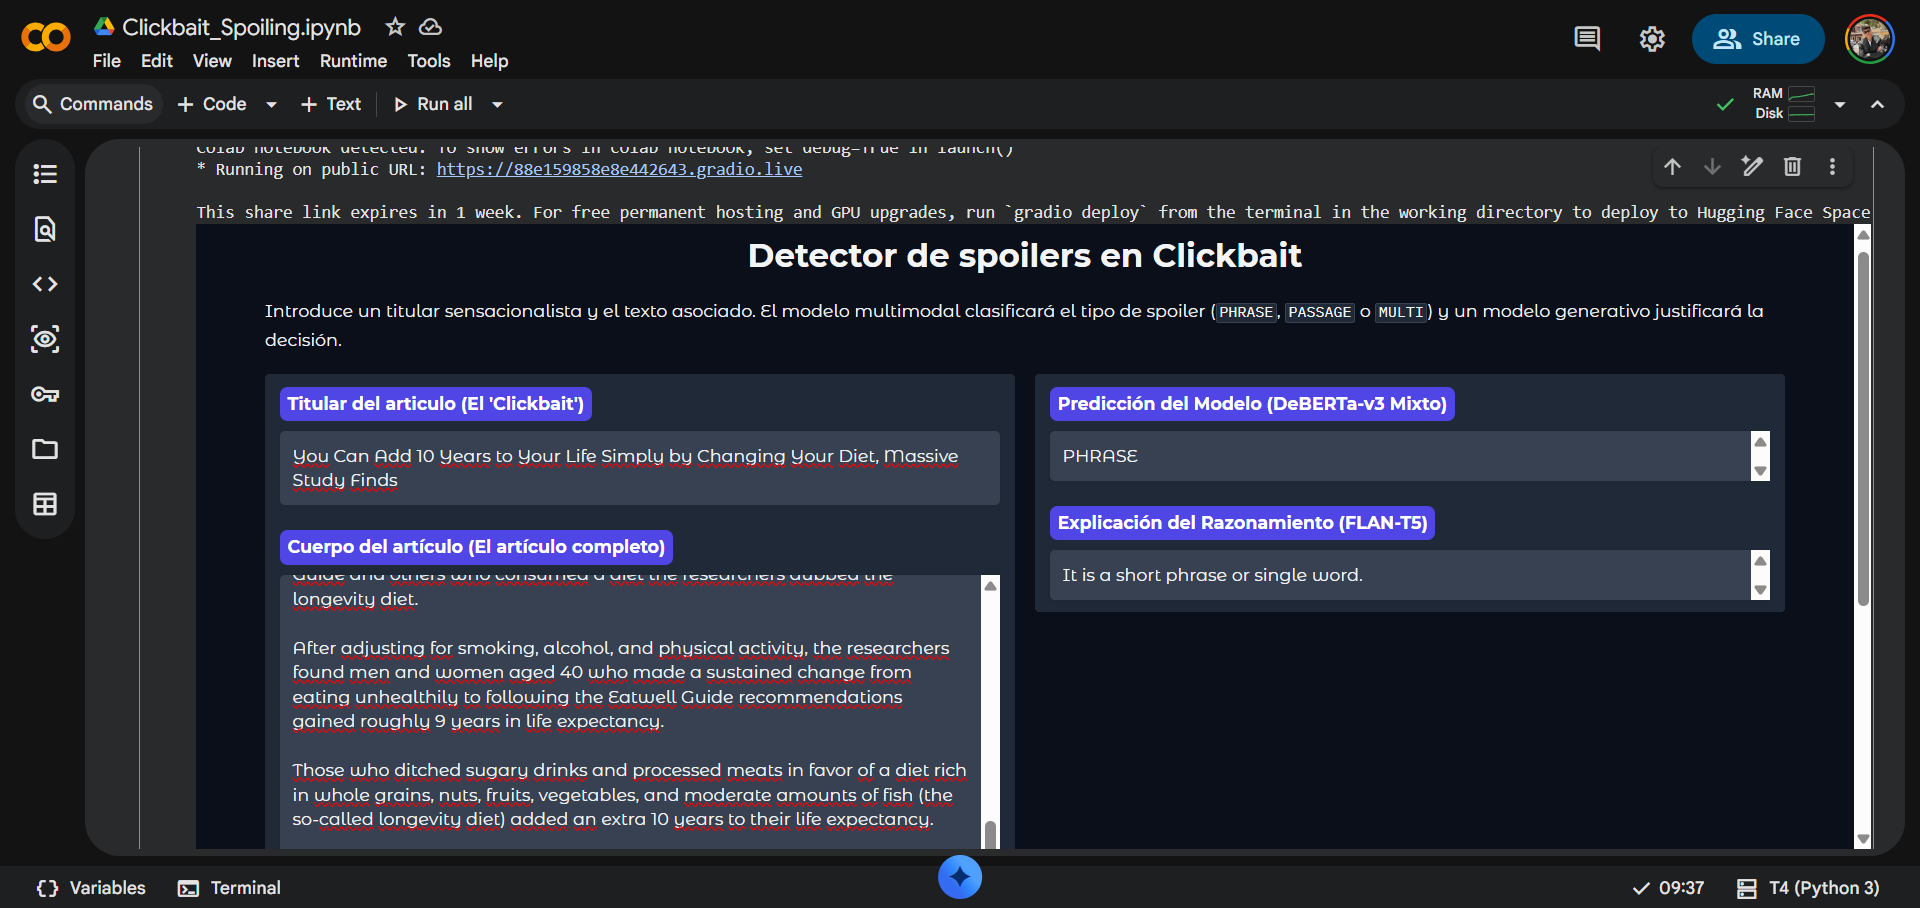